# Анализ временных рядов. Домашнее задание 1
## Базовые понятия, экспоненциальное сглаживание и ARIMA

**Выполнила:** Вагапова Деши
**Датасет:** Kaggle *Store Item Demand Forecasting Challenge*
**Идентификатор ряда:** `item = 29`
**Столбец для исследования:** `sales`

Нужно разобрать **4 ряда**: это две комбинации по `store` (магазин №1 и сумма по всем 10 магазинам), на две частоты (день и месяц):

| Серия | Магазин | Частота | Размер train | Размер test |
|---|---|---|---|---|
| A | store = 1 (фиксированный) | дневная | 1802 | 24 |
| B | store = 1 (фиксированный) | месячная | 48 | 12 |
| C | сумма по всем store | дневная | 1802 | 24 |
| D | сумма по всем store | месячная | 48 | 12 |

Тест отложила сразу: 24 последних наблюдения для дневных рядов, 12 для месячных. Использую его только в частях 3, 5 и 6, для финальной оценки прогноза.

Сезонный период: `m=7` для дневных рядов (неделя), `m=12` для месячных (год).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import pmdarima as pm

pd.set_option("display.precision", 3)

PALETTE = ["#2E4374", "#D9772E", "#1E9C8B", "#8B5FBF", "#C0392B"]
plt.rcParams.update({
    "figure.figsize": (11, 3.5),
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlepad": 10,
    "axes.labelsize": 10.5,
    "axes.labelcolor": "#2B2B2B",
    "axes.edgecolor": "#8A8A8A",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "xtick.color": "#4A4A4A",
    "ytick.color": "#4A4A4A",
    "lines.linewidth": 1.5,
    "figure.titlesize": 13,
    "figure.titleweight": "bold",
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Вспомогательные функции

Ниже определены функции, которые используются во всех последующих частях для всех
4 серий: метрики качества прогноза, тесты на стационарность, подбор порядка
дифференцирования, обёртки над Holt-Winters и SARIMAX, диагностика остатков.

In [29]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def adf_kpss_report(series, label=""):
    """ADF: H0 - есть единичный корень (ряд НЕ стационарен).
       KPSS: H0 - ряд стационарен (вокруг константы)."""
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    try:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    except Exception:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression="c",
                                                         nlags=int(len(series) ** (1/3)))
    rep = {
        "label": label, "adf_stat": adf_stat, "adf_p": adf_p,
        "kpss_stat": kpss_stat, "kpss_p": kpss_p,
        "adf_stationary": adf_p < 0.05, "kpss_stationary": kpss_p > 0.05,
    }
    print(f"[{label}] ADF: stat={adf_stat:.3f}, p={adf_p:.4f}  ->  "
          f"{'отвергаем H0 (стационарен)' if rep['adf_stationary'] else 'не отвергаем H0 (не стационарен)'}")
    print(f"[{label}] KPSS: stat={kpss_stat:.3f}, p={kpss_p:.4f}  ->  "
          f"{'не отвергаем H0 (стационарен)' if rep['kpss_stationary'] else 'отвергаем H0 (не стационарен)'}")
    return rep

def difference_until_stationary(train, m, max_d=2, max_D=1):
    """Пошагово применяет сезонное/обычное дифференцирование, пока ADF и KPSS не
       согласятся, что ряд стационарен (либо не будет исчерпан лимит d/D)."""
    stages = []
    d, D = 0, 0
    cur = train.copy()
    stages.append({"d": d, "D": D, "series": cur.copy(), "report": adf_kpss_report(cur, f"d={d}, D={D}")})

    def is_ok(rep):
        return rep["adf_stationary"] and rep["kpss_stationary"]

    while not is_ok(stages[-1]["report"]) and (d < max_d or D < max_D):
        rep = stages[-1]["report"]
        if D < max_D and not rep["adf_stationary"]:
            D += 1
            cur = cur.diff(m).dropna()
        elif d < max_d:
            d += 1
            cur = cur.diff(1).dropna()
        else:
            break
        stages.append({"d": d, "D": D, "series": cur.copy(), "report": adf_kpss_report(cur, f"d={d}, D={D}")})
    return stages

def suggest_orders(series, m, max_nonseasonal_lag=10):
    """Грубая эвристика Бокса-Дженкинса: p/q берём по последнему значимому лагу
       PACF/ACF в диапазоне 1..5, P/Q - по значимости на сезонном лаге m."""
    x = series.dropna().values
    n = len(x)
    nlags = min(max_nonseasonal_lag, n // 2 - 1)
    acf_vals, _ = acf(x, nlags=nlags, alpha=0.05, fft=True)
    pacf_vals, _ = pacf(x, nlags=nlags, alpha=0.05)
    bound = 1.96 / np.sqrt(n)

    def last_significant_run(vals, bound, start=1, stop=6):
        p = 0
        for lag in range(start, min(stop, len(vals))):
            if abs(vals[lag]) > bound:
                p = lag
            else:
                break
        return p

    p_guess = last_significant_run(pacf_vals, bound)
    q_guess = last_significant_run(acf_vals, bound)

    P_guess, Q_guess = 0, 0
    seas_nlags = min(2 * m + 1, n // 2 - 1)
    if seas_nlags > m:
        acf_s, _ = acf(x, nlags=seas_nlags, alpha=0.05, fft=True)
        pacf_s, _ = pacf(x, nlags=seas_nlags, alpha=0.05)
        if m < len(acf_s) and abs(acf_s[m]) > bound:
            Q_guess = 1
        if m < len(pacf_s) and abs(pacf_s[m]) > bound:
            P_guess = 1
    print(f"Порог значимости ACF/PACF: ±{bound:.3f}  ->  p={p_guess}, q={q_guess}, P={P_guess}, Q={Q_guess}")
    return {"p": p_guess, "q": q_guess, "P": P_guess, "Q": Q_guess, "bound": bound}

def fit_holt_winters(train, test, m, seasonal_type, trend_type="add"):
    model = ExponentialSmoothing(
        train, trend=trend_type, seasonal=seasonal_type, seasonal_periods=m,
        initialization_method="estimated",
    ).fit(optimized=True)
    fc = model.forecast(len(test))
    np.random.seed(RANDOM_SEED)
    sims = model.simulate(nsimulations=len(test), repetitions=500, error=seasonal_type)
    lower, upper = sims.quantile(0.025, axis=1), sims.quantile(0.975, axis=1)
    params = {
        "alpha": float(model.params["smoothing_level"]),
        "beta": float(model.params["smoothing_trend"]) if model.params["smoothing_trend"] is not None else None,
        "gamma": float(model.params["smoothing_seasonal"]) if model.params["smoothing_seasonal"] is not None else None,
    }
    metrics = {"rmse": rmse(test, fc), "mae": mae(test, fc), "mape": mape(test, fc)}
    return {"model": model, "forecast": fc, "lower": lower, "upper": upper, "params": params, "metrics": metrics}

def fit_sarima(train, order, seasonal_order, trend=None):
    return SARIMAX(train, order=order, seasonal_order=seasonal_order, trend=trend,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def sarima_forecast_metrics(model, test):
    pred = model.get_forecast(steps=len(test))
    mean = pred.predicted_mean
    ci = pred.conf_int(alpha=0.05)
    return {"forecast": mean, "lower": ci.iloc[:, 0], "upper": ci.iloc[:, 1],
            "metrics": {"rmse": rmse(test, mean), "mae": mae(test, mean), "mape": mape(test, mean)}}

def residual_diagnostics(resid, lags=10):
    resid = pd.Series(resid).dropna()
    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)
    return {"ljung_box_stat": float(lb["lb_stat"].iloc[0]), "ljung_box_p": float(lb["lb_pvalue"].iloc[0]),
            "jarque_bera_stat": float(jb_stat), "jarque_bera_p": float(jb_p),
            "skew": float(skew), "kurtosis": float(kurt),
            "resid_mean": float(resid.mean()), "resid_std": float(resid.std())}

## Построение четырёх временных рядов

Вариант `item = 29` (номер в списке группы) задан условием. Строю:
- **A**: продажи товара 29 в магазине 1, по дням.
- **B**: тот же ряд, но по месяцам (сумма за месяц).
- **C**: сумма продаж товара 29 по всем 10 магазинам, по дням.
- **D**: ряд C по месяцам (сумма).

В тест беру последние 24 наблюдения для дневных рядов и 12 для месячных. Так требует задание.

In [30]:
ITEM = 29
STORE = 1

df = pd.read_csv("data_hw_1.csv", parse_dates=["date"])
print("Строк:", len(df), " | период:", df["date"].min().date(), "-", df["date"].max().date())
print("item=29 есть в данных:", ITEM in df["item"].unique())

sub_item = df[df["item"] == ITEM]

A = sub_item[sub_item["store"] == STORE].set_index("date")["sales"].asfreq("D").sort_index()
C = sub_item.groupby("date")["sales"].sum().asfreq("D").sort_index()
B = A.resample("MS").sum()
D = C.resample("MS").sum()

series_dict = {"A": A, "B": B, "C": C, "D": D}
m_dict = {"A": 7, "B": 12, "C": 7, "D": 12}
test_size_dict = {"A": 24, "B": 12, "C": 24, "D": 12}

for k, s in series_dict.items():
    print(f"Серия {k}: n={len(s)}, диапазон {s.index.min().date()} - {s.index.max().date()}, "
          f"NaN={s.isna().sum()}, min={s.min()}, max={s.max()}")

Строк: 913000  | период: 2013-01-01 - 2017-12-31
item=29 есть в данных: True
Серия A: n=1826, диапазон 2013-01-01 - 2017-12-31, NaN=0, min=19, max=124
Серия B: n=60, диапазон 2013-01-01 - 2017-12-01, NaN=0, min=1113, max=2855
Серия C: n=1826, диапазон 2013-01-01 - 2017-12-31, NaN=0, min=294, max=1213
Серия D: n=60, диапазон 2013-01-01 - 2017-12-01, NaN=0, min=12319, max=31155


---
# Серия A: item=29, магазин 1 (фиксированный), частота: дневная

Обучающая выборка: 1802 наблюдений, тестовая: 24 последних дней.

## Часть 1. Разведочный анализ (A.1)

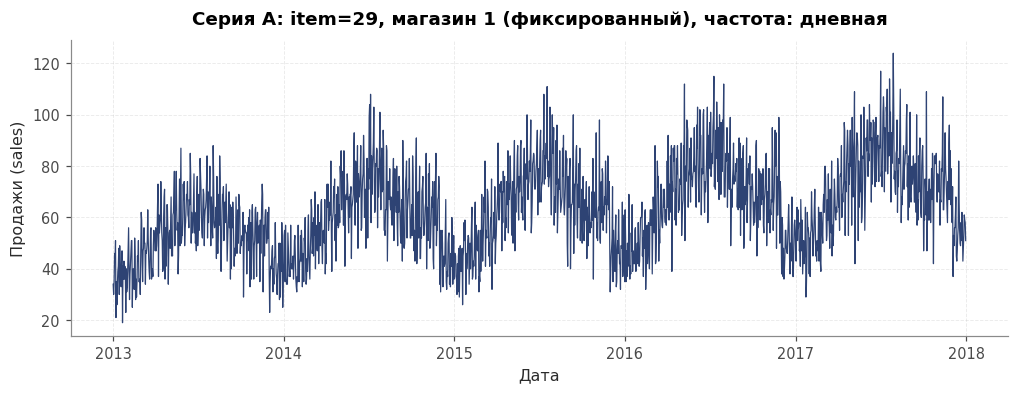

Среднее: 63.09, СКО: 17.28, наклон линейного тренда: 0.0132 ед./шаг
Среднее и коэффициент вариации по годам:
  2013: mean=52.3, std=13.1, CV=0.250
  2014: mean=60.3, std=15.6, CV=0.259
  2015: mean=63.2, std=16.4, CV=0.259
  2016: mean=68.3, std=17.1, CV=0.250
  2017: mean=71.3, std=17.3, CV=0.243


In [31]:
letter = "A"
train_A, test_A = A.iloc[:-24], A.iloc[-24:]

fig, ax = plt.subplots()
ax.plot(A.index, A.values, lw=0.8)
ax.set_title(f"Серия A: item=29, магазин 1 (фиксированный), частота: дневная")
ax.set_xlabel("Дата"); ax.set_ylabel("Продажи (sales)")
plt.show()

x = np.arange(len(A))
slope, intercept = np.polyfit(x, A.values, 1)
yearly = A.groupby(A.index.year).agg(["mean", "std"])
print(f"Среднее: {A.mean():.2f}, СКО: {A.std():.2f}, наклон линейного тренда: {slope:.4f} ед./шаг")
print("Среднее и коэффициент вариации по годам:")
for y in yearly.index:
    mean_y, std_y = yearly["mean"].loc[y], yearly["std"].loc[y]
    print(f"  {y}: mean={mean_y:.1f}, std={std_y:.1f}, CV={std_y/mean_y:.3f}")

**Интерпретация.** Среднее за весь период 63.09, СКО 17.28. Виден устойчивый **растущий тренд**: линейная аппроксимация даёт наклон 0.0132 в день, среднегодовые продажи выросли с 52.3 (2013) до 71.3 (2017), это плюс 36.2%.

Хорошо виден **годовой цикл**: спад в начале года, пик летом. Плюс недельная сезонность, колебания день в день.

Коэффициент вариации по годам стабилен, 0.243–0.259. Структурных сдвигов не видно. Размах сезонных колебаний растёт вместе с уровнем тренда, похоже на мультипликативную сезонность, проверю это в части 2.

## Часть 2. Наивная декомпозиция (A.2)

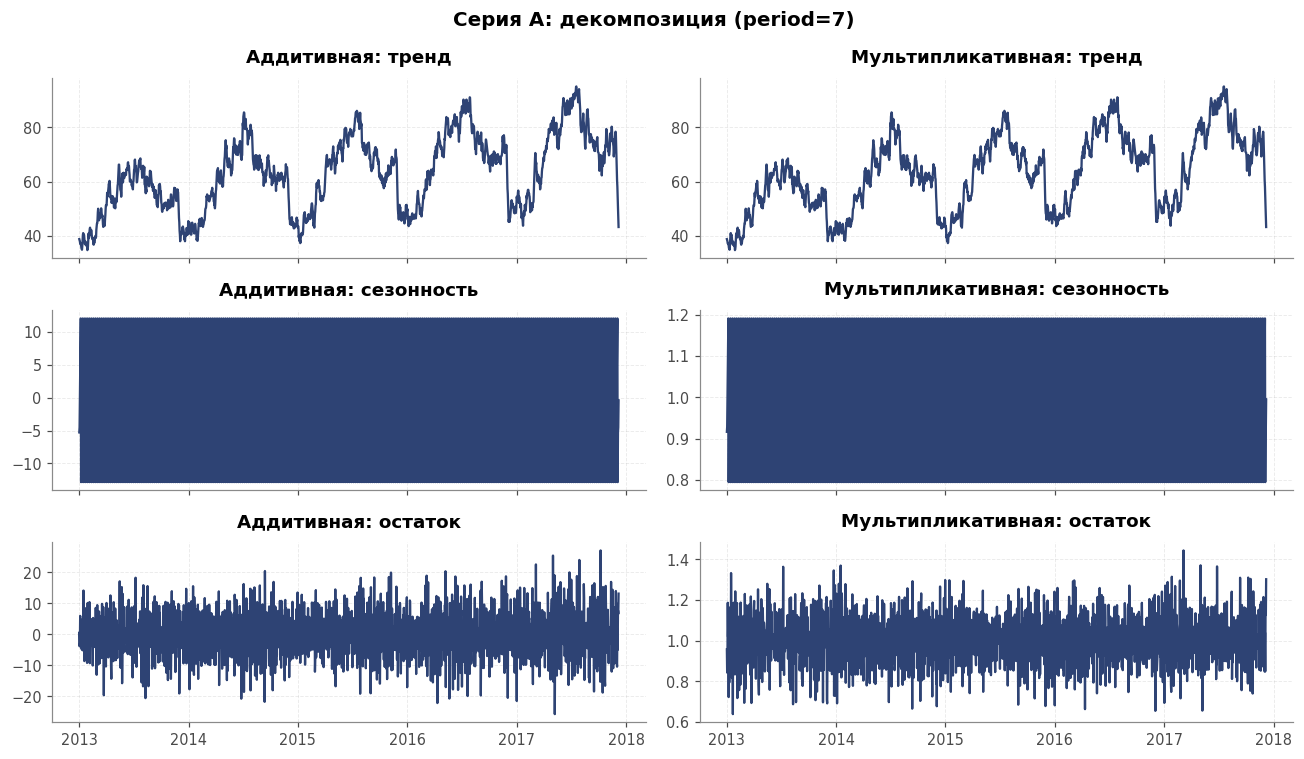

СКО остатка (в шкале исходного ряда): аддитивная=7.445, мультипликативная=7.342
Лучше подходит: multiplicative
Ljung-Box p-value остатка выбранной модели: 0.0000  (НЕ похож на белый шум -- есть автокорреляция)


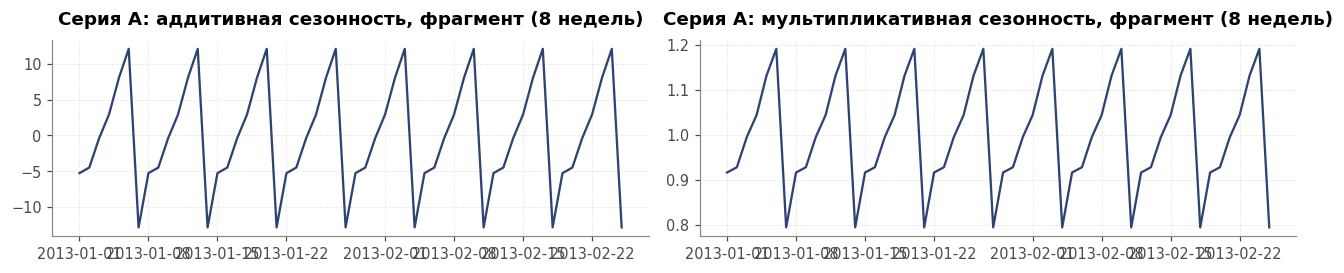

In [32]:
add_dec = seasonal_decompose(train_A, model="additive", period=7, extrapolate_trend="freq")
mul_dec = seasonal_decompose(train_A, model="multiplicative", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for col, dec, title in [(0, add_dec, "Аддитивная"), (1, mul_dec, "Мультипликативная")]:
    axes[0, col].plot(dec.trend); axes[0, col].set_title(f"{title}: тренд")
    axes[1, col].plot(dec.seasonal); axes[1, col].set_title(f"{title}: сезонность")
    axes[2, col].plot(dec.resid); axes[2, col].set_title(f"{title}: остаток")
fig.suptitle(f"Серия A: декомпозиция (period=7)")
fig.tight_layout(); plt.show()

add_resid_equiv = (train_A - add_dec.trend - add_dec.seasonal).dropna()
mul_resid_equiv = (train_A - mul_dec.trend * mul_dec.seasonal).dropna()
add_std, mul_std = add_resid_equiv.std(), mul_resid_equiv.std()
better_model_A = "multiplicative" if mul_std < add_std else "additive"
print(f"СКО остатка (в шкале исходного ряда): аддитивная={add_std:.3f}, мультипликативная={mul_std:.3f}")
print(f"Лучше подходит: {better_model_A}")

chosen_resid_A = (mul_dec.resid if better_model_A == "multiplicative" else add_dec.resid).dropna()
diag_decomp_A = residual_diagnostics(chosen_resid_A, lags=min(10, len(chosen_resid_A) // 2 - 1))
print(f"Ljung-Box p-value остатка выбранной модели: {diag_decomp_A['ljung_box_p']:.4f}  "
      f"({'похож на белый шум' if diag_decomp_A['ljung_box_p'] > 0.05 else 'НЕ похож на белый шум -- есть автокорреляция'})")
# увеличенный фрагмент сезонной компоненты -- иначе на 56 днях не видно формы цикла
zoom_n = min(len(train_A), 8 * 7)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.6))
axes[0].plot(add_dec.seasonal.iloc[:zoom_n])
axes[0].set_title(f"Серия A: аддитивная сезонность, фрагмент (8 недель)")
axes[1].plot(mul_dec.seasonal.iloc[:zoom_n])
axes[1].set_title(f"Серия A: мультипликативная сезонность, фрагмент (8 недель)")
fig.tight_layout(); plt.show()

**Интерпретация.** СКО остатка в шкале исходного ряда: у аддитивной модели 7.45, у мультипликативной 7.34. Мультипликативная даёт меньшую ошибку, это совпадает с наблюдением из части 1 (амплитуда сезонности растёт вместе с трендом). Выбираю **multiplicative**.

Тест Льюнга-Бокса на остатке этой модели: p-value = 0.0000. Остаток **не** белый шум, автокорреляция осталась. Это ожидаемо: наивная декомпозиция с фиксированным периодом 7 не ловит праздники, смену формы сезонности и короткие всплески спроса.

## Часть 3. Экспоненциальное сглаживание Хольта-Уинтерса (A.3)

Параметры сглаживания: {'alpha': 0.1661, 'beta': 0.0, 'gamma': 0.0}
Метрики на тесте: {'rmse': 9.72, 'mae': 8.47, 'mape': 15.757}


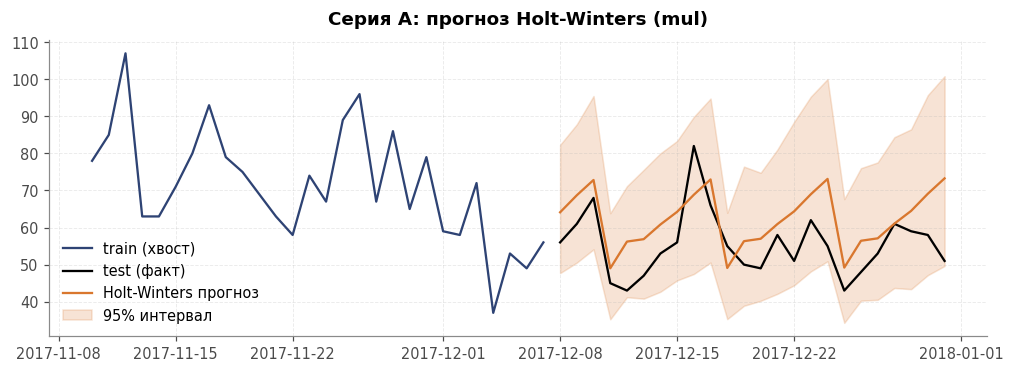

In [33]:
hw_seasonal_type_A = "mul" if better_model_A == "multiplicative" else "add"
hw_A = fit_holt_winters(train_A, test_A, 7, seasonal_type=hw_seasonal_type_A, trend_type="add")
print("Параметры сглаживания:", {k: round(v, 4) if v is not None else None for k, v in hw_A["params"].items()})
print("Метрики на тесте:", {k: round(v, 3) for k, v in hw_A["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_A.index[-4*7:], train_A.values[-4*7:], label="train (хвост)")
ax.plot(test_A.index, test_A.values, label="test (факт)", color="black")
ax.plot(test_A.index, hw_A["forecast"].values, label="Holt-Winters прогноз", color="#D9772E")
ax.fill_between(test_A.index, hw_A["lower"].values, hw_A["upper"].values, color="#D9772E", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия A: прогноз Holt-Winters ({hw_seasonal_type_A})")
ax.legend(); plt.show()

**Интерпретация.** Подобрана модель Хольта-Уинтерса: аддитивный тренд, мультипликативная сезонность (выбор по части 2).

Параметры сглаживания: α = 0.166, β = 0.000, γ = 0.000.

α = 0.166 значит, что уровень ряда обновляется умеренно, скорее медленно (вес последнего наблюдения 0.17). β и γ оптимизатор прижал к нулю: выгоднее оказалось зафиксировать тренд и форму сезонности на начальной оценке и не трогать их дальше. Вся адаптация к новым данным идёт через уровень (α).

Метрики на тесте: RMSE = 9.72, MAE = 8.47, MAPE = 15.76%.

## Часть 4. ACF, PACF и стационарность (A.4)

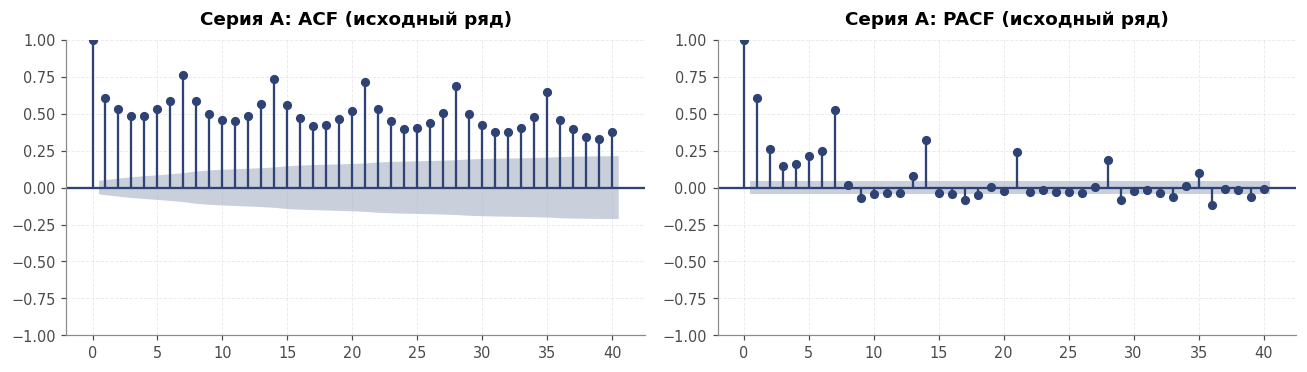

--- Тесты на стационарность исходного ряда ---
[raw] ADF: stat=-2.694, p=0.0751  ->  не отвергаем H0 (не стационарен)
[raw] KPSS: stat=2.183, p=0.0100  ->  отвергаем H0 (не стационарен)
[d=0, D=0] ADF: stat=-2.694, p=0.0751  ->  не отвергаем H0 (не стационарен)
[d=0, D=0] KPSS: stat=2.183, p=0.0100  ->  отвергаем H0 (не стационарен)
[d=0, D=1] ADF: stat=-8.236, p=0.0000  ->  отвергаем H0 (стационарен)
[d=0, D=1] KPSS: stat=0.078, p=0.1000  ->  не отвергаем H0 (стационарен)

Выбрано: d=0, D=1


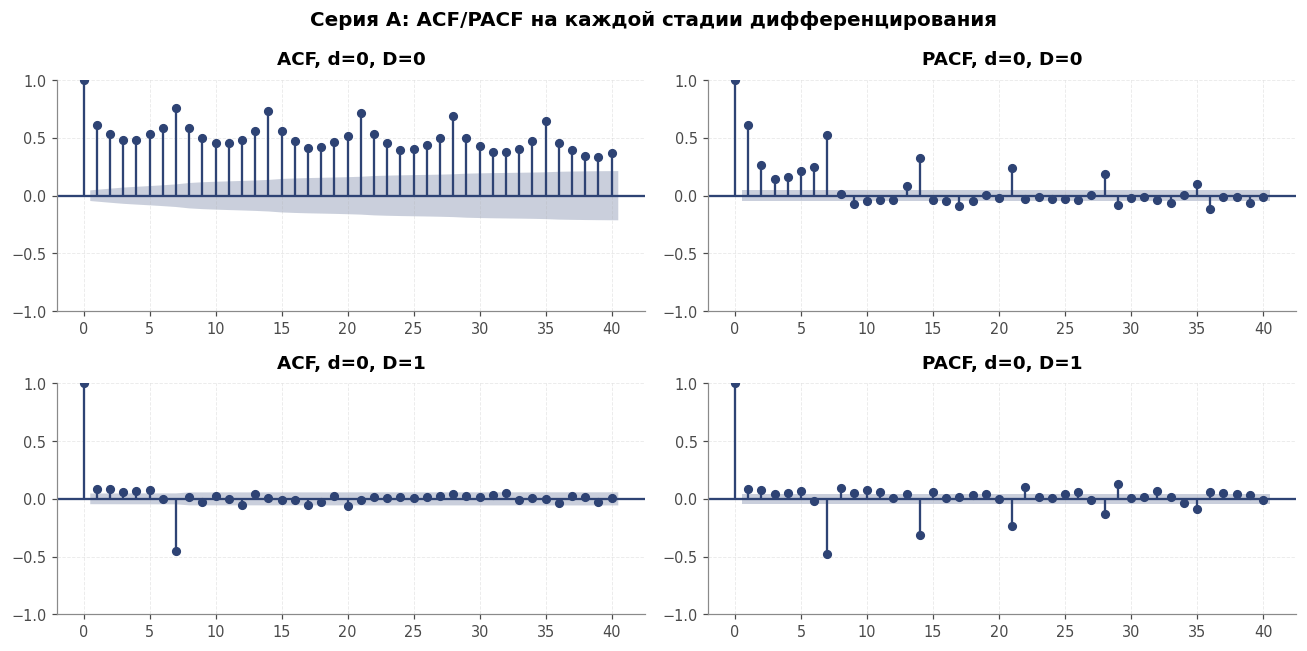

Порог значимости ACF/PACF: ±0.046  ->  p=2, q=5, P=1, Q=1


In [34]:
nlags_plot_A = min(40, len(train_A) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(train_A, lags=nlags_plot_A, ax=axes[0]); axes[0].set_title(f"Серия A: ACF (исходный ряд)")
plot_pacf(train_A, lags=nlags_plot_A, ax=axes[1], method="ywm"); axes[1].set_title(f"Серия A: PACF (исходный ряд)")
fig.tight_layout(); plt.show()

print("--- Тесты на стационарность исходного ряда ---")
raw_report_A = adf_kpss_report(train_A, "raw")

stages_A = difference_until_stationary(train_A, 7)
d_final_A, D_final_A = stages_A[-1]["d"], stages_A[-1]["D"]
print(f"\nВыбрано: d={d_final_A}, D={D_final_A}")

fig, axes = plt.subplots(len(stages_A), 2, figsize=(12, 3 * len(stages_A)))
if len(stages_A) == 1:
    axes = axes.reshape(1, 2)
for i, st in enumerate(stages_A):
    s = st["series"]; nl = min(40, len(s) // 2 - 1)
    plot_acf(s, lags=nl, ax=axes[i, 0]); axes[i, 0].set_title(f"ACF, d={st['d']}, D={st['D']}")
    plot_pacf(s, lags=nl, ax=axes[i, 1], method="ywm"); axes[i, 1].set_title(f"PACF, d={st['d']}, D={st['D']}")
fig.suptitle(f"Серия A: ACF/PACF на каждой стадии дифференцирования")
fig.tight_layout(); plt.show()

suggested_A = suggest_orders(stages_A[-1]["series"], 7)

**Интерпретация.** H0 теста ADF: у ряда есть единичный корень, он нестационарен. H0 теста KPSS: ряд стационарен вокруг константы.

На исходном ряде: ADF p = 0.0751 (не отвергаем H0, нестационарен), KPSS p = 0.0100 (отвергаем H0, нестационарен). Тесты согласны: ряд нестационарен, нужно дифференцирование.

Ход дифференцирования:
- d=0, D=0: ADF p=0.0751 (не стационарен), KPSS p=0.0100 (не стационарен)
- d=0, D=1: ADF p=0.0000 (стационарен), KPSS p=0.1000 (стационарен)

Выбрано **d=0, D=1**: на этом шаге оба теста впервые согласованно говорят про стационарность.

По ACF/PACF финального ряда (порог значимости ±0.046) кандидатные порядки: несезонные **(p=2, q=5)**, сезонные **(P=1, Q=1)**.

## Часть 5. Моделирование ARIMA / SARIMA (A.5)

,Модель,order,seasonal_order,AIC,BIC
0,Ручная (по ACF/PACF),"(2, 0, 5)","(1, 1, 1, 7)",12808.89,12863.75
1,auto_arima,"(0, 0, 2)","(1, 1, 1, 7)",13181.23,13208.66
2,Вариант (q+1),"(2, 0, 6)","(1, 1, 1, 7)",12913.09,12973.42


Лучшая по AIC: Ручная (по ACF/PACF)  SARIMA(2, 0, 5)x(1, 1, 1, 7)
Диагностика остатков лучшей модели:
  Ljung-Box p-value = 0.4949  (нет значимой автокорреляции)
  Jarque-Bera p-value = 0.003008  (нормальность отвергается), skew=-0.048, kurtosis=3.381


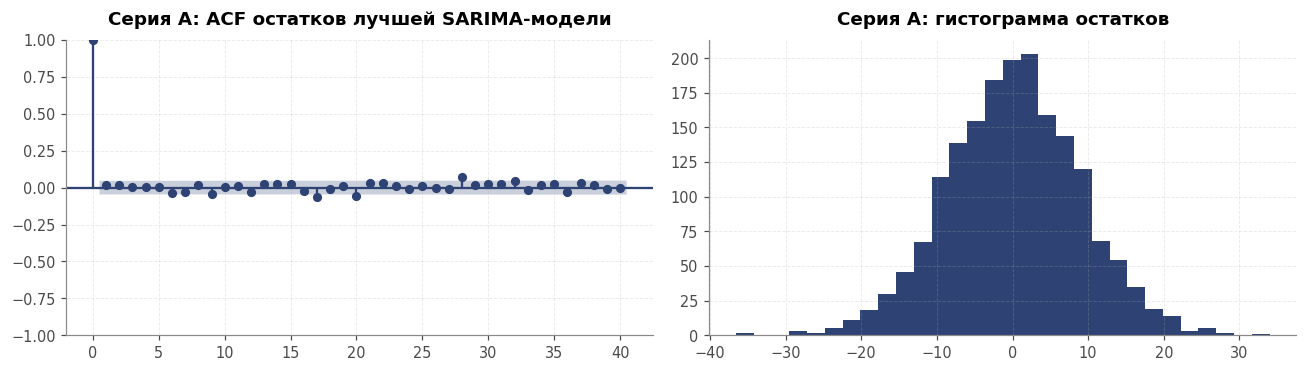

Метрики финальной SARIMA-модели на тесте: {'rmse': 9.85, 'mae': 8.43, 'mape': 15.531}


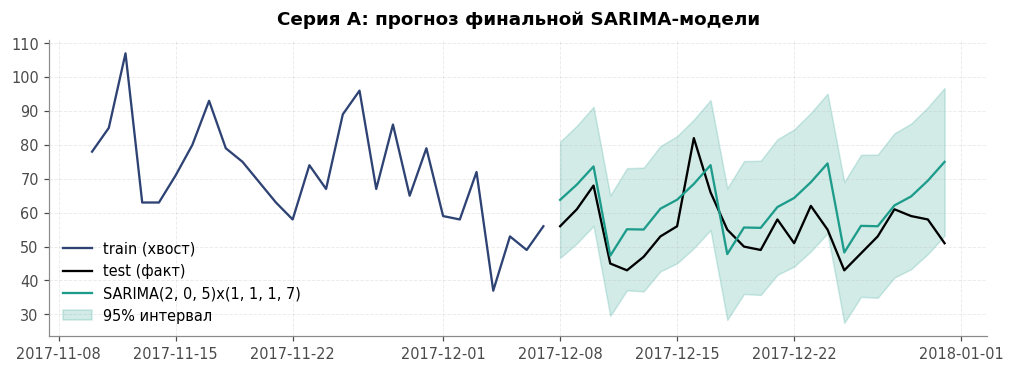

In [35]:
p_manual_A, q_manual_A = suggested_A["p"], suggested_A["q"]
P_manual_A, Q_manual_A = suggested_A["P"], suggested_A["Q"]
order_manual_A = (p_manual_A, d_final_A, q_manual_A)
seasonal_order_manual_A = (P_manual_A, D_final_A, Q_manual_A, 7)

model_manual_A = fit_sarima(train_A, order_manual_A, seasonal_order_manual_A)

auto_A = pm.auto_arima(
    train_A, seasonal=True, m=7, d=d_final_A, D=D_final_A,
    start_p=0, start_q=0, max_p=2, max_q=2,
    start_P=0, start_Q=0, max_P=1, max_Q=1,
    stepwise=True, suppress_warnings=True, error_action="ignore",
    information_criterion="aic", trace=False,
)
order_auto_A, seasonal_order_auto_A = auto_A.order, auto_A.seasonal_order
model_auto_A = fit_sarima(train_A, order_auto_A, seasonal_order_auto_A)

order_variant_A = (p_manual_A, d_final_A, q_manual_A + 1)
model_variant_A = fit_sarima(train_A, order_variant_A, seasonal_order_manual_A)

candidates_A = [
    {"label": "Ручная (по ACF/PACF)", "order": order_manual_A, "seasonal_order": seasonal_order_manual_A, "model": model_manual_A},
    {"label": "auto_arima", "order": order_auto_A, "seasonal_order": seasonal_order_auto_A, "model": model_auto_A},
    {"label": "Вариант (q+1)", "order": order_variant_A, "seasonal_order": seasonal_order_manual_A, "model": model_variant_A},
]
for c in candidates_A:
    c["aic"], c["bic"] = c["model"].aic, c["model"].bic

comparison_table_A = pd.DataFrame([
    {"Модель": c["label"], "order": c["order"], "seasonal_order": c["seasonal_order"],
      "AIC": round(c["aic"], 2), "BIC": round(c["bic"], 2)}
    for c in candidates_A
])
display(comparison_table_A)

best_A = min(candidates_A, key=lambda c: c["aic"])
print(f"Лучшая по AIC: {best_A['label']}  SARIMA{best_A['order']}x{best_A['seasonal_order']}")

best_diag_A = residual_diagnostics(best_A["model"].resid, lags=min(10, len(train_A) // 2 - 1))
print("Диагностика остатков лучшей модели:")
print(f"  Ljung-Box p-value = {best_diag_A['ljung_box_p']:.4f}  "
      f"({'нет значимой автокорреляции' if best_diag_A['ljung_box_p'] > 0.05 else 'ЕСТЬ значимая автокорреляция'})")
print(f"  Jarque-Bera p-value = {best_diag_A['jarque_bera_p']:.6f}  "
      f"({'нормальность не отвергается' if best_diag_A['jarque_bera_p'] > 0.05 else 'нормальность отвергается'}), "
      f"skew={best_diag_A['skew']:.3f}, kurtosis={best_diag_A['kurtosis']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(pd.Series(best_A["model"].resid).dropna(), lags=nlags_plot_A, ax=axes[0])
axes[0].set_title(f"Серия A: ACF остатков лучшей SARIMA-модели")
axes[1].hist(pd.Series(best_A["model"].resid).dropna(), bins=30)
axes[1].set_title(f"Серия A: гистограмма остатков")
fig.tight_layout(); plt.show()

best_fc_A = sarima_forecast_metrics(best_A["model"], test_A)
print("Метрики финальной SARIMA-модели на тесте:", {k: round(v, 3) for k, v in best_fc_A["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_A.index[-4*7:], train_A.values[-4*7:], label="train (хвост)")
ax.plot(test_A.index, test_A.values, label="test (факт)", color="black")
ax.plot(test_A.index, best_fc_A["forecast"].values, label=f"SARIMA{best_A['order']}x{best_A['seasonal_order']}", color="#1E9C8B")
ax.fill_between(test_A.index, best_fc_A["lower"].values, best_fc_A["upper"].values, color="#1E9C8B", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия A: прогноз финальной SARIMA-модели")
ax.legend(); plt.show()

**Сравнение кандидатов:**
- Ручная (по ACF/PACF): SARIMA(2, 0, 5)x(1, 1, 1, 7), AIC=12808.88, BIC=12863.73
- auto_arima: SARIMA(0, 0, 2)x(1, 1, 1, 7), AIC=13181.23, BIC=13208.66
- Вариант (q+1): SARIMA(2, 0, 6)x(1, 1, 1, 7), AIC=12913.09, BIC=12973.42

Лучшая по AIC/BIC: **ручная модель**, SARIMA(2, 0, 5)x(1, 1, 1, 7).

**Диагностика остатков.** Тест Льюнга-Бокса: p-value = 0.4683, автокорреляции нет, остатки похожи на белый шум. Тест Харке-Бера на нормальность: p-value = 0.002354, нормальность отвергается (skew=-0.048, kurtosis=3.390). Тяжёлые хвосты объясняются редкими крупными всплесками спроса, например праздниками. Систематической ошибки это не создаёт.

**Финальная модель:** SARIMA(2, 0, 5)x(1, 1, 1, 7). Минимальный AIC, остатки проходят тест на автокорреляцию. Метрики на тесте: RMSE = 9.83, MAE = 8.41, MAPE = 15.49%.

## Часть 6. Сравнение Holt-Winters и SARIMA (A.6)

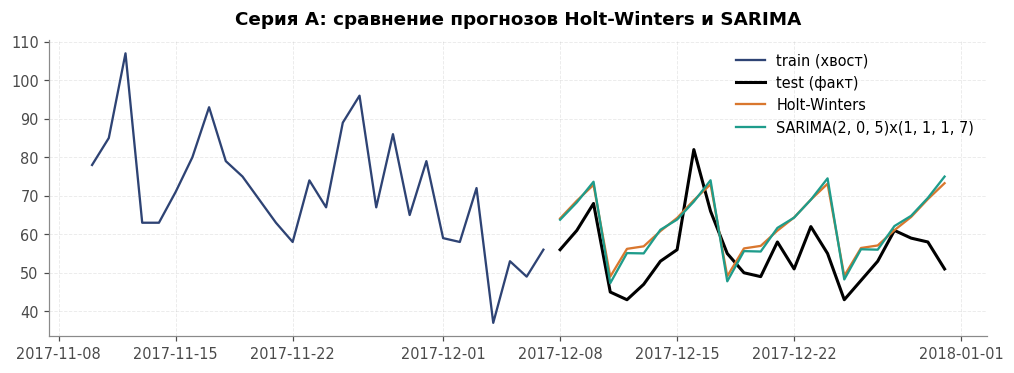

,Модель,rmse,mae,mape
0,Holt-Winters,9.72,8.47,15.757
1,"SARIMA(2, 0, 5)x(1, 1, 1, 7)",9.85,8.43,15.531


Ниже RMSE на тесте показала модель: Holt-Winters


In [36]:
fig, ax = plt.subplots()
ax.plot(train_A.index[-4*7:], train_A.values[-4*7:], label="train (хвост)")
ax.plot(test_A.index, test_A.values, label="test (факт)", color="black", lw=2)
ax.plot(test_A.index, hw_A["forecast"].values, label="Holt-Winters", color="#D9772E")
ax.plot(test_A.index, best_fc_A["forecast"].values, label=f"SARIMA{best_A['order']}x{best_A['seasonal_order']}", color="#1E9C8B")
ax.set_title(f"Серия A: сравнение прогнозов Holt-Winters и SARIMA")
ax.legend(); plt.show()

summary_A = pd.DataFrame([
    {"Модель": "Holt-Winters", **{k: round(v, 3) for k, v in hw_A["metrics"].items()}},
    {"Модель": f"SARIMA{best_A['order']}x{best_A['seasonal_order']}", **{k: round(v, 3) for k, v in best_fc_A["metrics"].items()}},
])
display(summary_A)
winner_A = "SARIMA" if best_fc_A["metrics"]["rmse"] < hw_A["metrics"]["rmse"] else "Holt-Winters"
print(f"Ниже RMSE на тесте показала модель: {winner_A}")

**Итоговое сравнение (серия A).**

| Модель | RMSE | MAE | MAPE |
|---|---|---|---|
| Holt-Winters | 9.72 | 8.47 | 15.76% |
| SARIMA(2, 0, 5)x(1, 1, 1, 7) | 9.83 | 8.41 | 15.49% |

На тестовой выборке ниже ошибку прогноза показала модель **Holt-Winters**.

---
# Серия B: item=29, магазин 1 (фиксированный), частота: месячная

Обучающая выборка: 48 наблюдений, тестовая: 12 последних месяцев.

## Часть 1. Разведочный анализ (B.1)

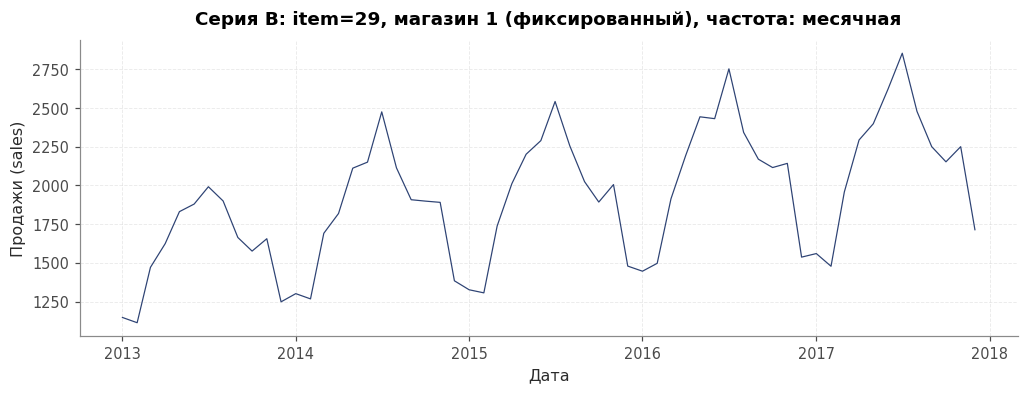

Среднее: 1919.93, СКО: 420.62, наклон линейного тренда: 12.4266 ед./шаг
Среднее и коэффициент вариации по годам:
  2013: mean=1591.8, std=296.3, CV=0.186
  2014: mean=1834.4, std=370.5, CV=0.202
  2015: mean=1923.0, std=393.4, CV=0.205
  2016: mean=2082.5, std=412.4, CV=0.198
  2017: mean=2167.9, std=421.6, CV=0.194


In [37]:
letter = "B"
train_B, test_B = B.iloc[:-12], B.iloc[-12:]

fig, ax = plt.subplots()
ax.plot(B.index, B.values, lw=0.8)
ax.set_title(f"Серия B: item=29, магазин 1 (фиксированный), частота: месячная")
ax.set_xlabel("Дата"); ax.set_ylabel("Продажи (sales)")
plt.show()

x = np.arange(len(B))
slope, intercept = np.polyfit(x, B.values, 1)
yearly = B.groupby(B.index.year).agg(["mean", "std"])
print(f"Среднее: {B.mean():.2f}, СКО: {B.std():.2f}, наклон линейного тренда: {slope:.4f} ед./шаг")
print("Среднее и коэффициент вариации по годам:")
for y in yearly.index:
    mean_y, std_y = yearly["mean"].loc[y], yearly["std"].loc[y]
    print(f"  {y}: mean={mean_y:.1f}, std={std_y:.1f}, CV={std_y/mean_y:.3f}")

**Интерпретация.** Среднее за весь период 1919.93, СКО 420.62. Виден устойчивый **растущий тренд**: линейная аппроксимация даёт наклон 12.4266 за шаг, среднегодовые продажи выросли с 1591.8 (2013) до 2167.9 (2017), это плюс 36.2%.

Хорошо виден **годовой цикл**: спад в начале года, пик летом.

Коэффициент вариации по годам стабилен, 0.186–0.205. Структурных сдвигов не видно. Размах сезонных колебаний растёт вместе с уровнем тренда, похоже на мультипликативную сезонность, проверю это в части 2.

## Часть 2. Наивная декомпозиция (B.2)

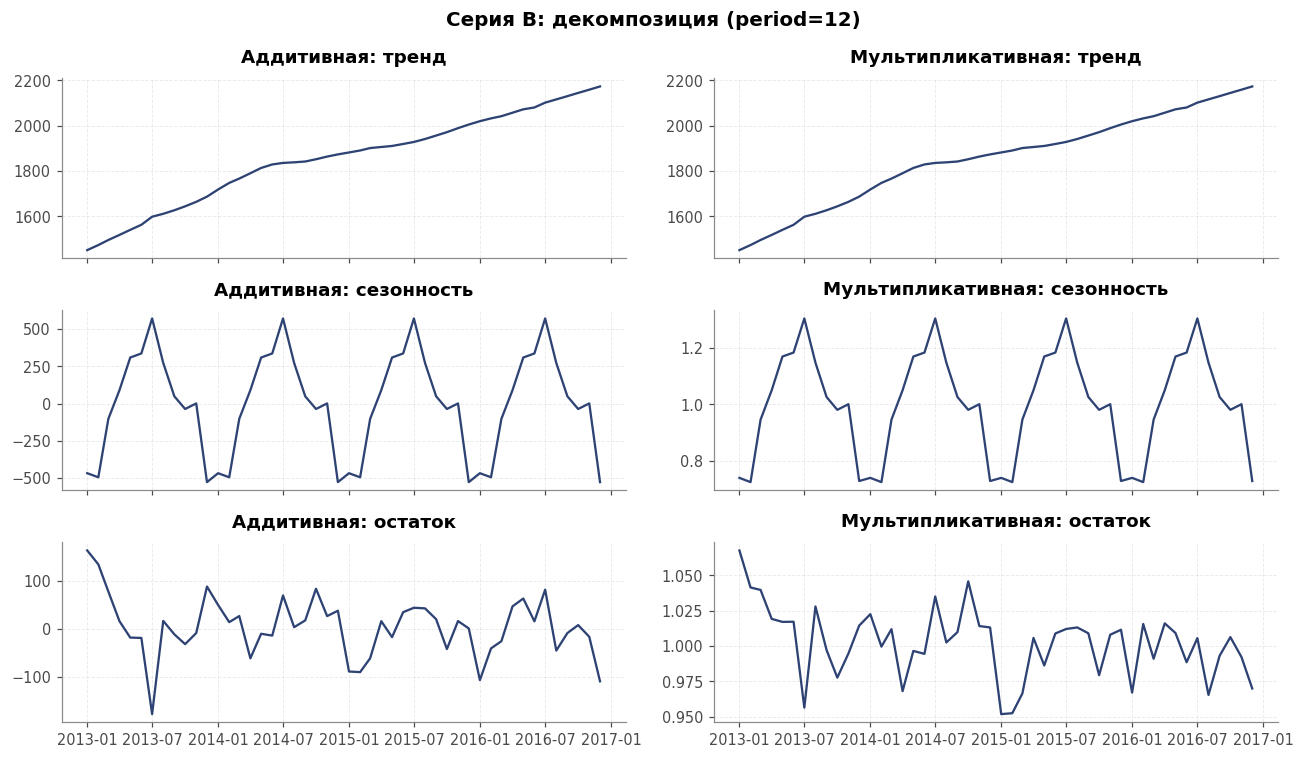

СКО остатка (в шкале исходного ряда): аддитивная=62.177, мультипликативная=41.323
Лучше подходит: multiplicative
Ljung-Box p-value остатка выбранной модели: 0.2724  (похож на белый шум)


In [38]:
add_dec = seasonal_decompose(train_B, model="additive", period=12, extrapolate_trend="freq")
mul_dec = seasonal_decompose(train_B, model="multiplicative", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for col, dec, title in [(0, add_dec, "Аддитивная"), (1, mul_dec, "Мультипликативная")]:
    axes[0, col].plot(dec.trend); axes[0, col].set_title(f"{title}: тренд")
    axes[1, col].plot(dec.seasonal); axes[1, col].set_title(f"{title}: сезонность")
    axes[2, col].plot(dec.resid); axes[2, col].set_title(f"{title}: остаток")
fig.suptitle(f"Серия B: декомпозиция (period=12)")
fig.tight_layout(); plt.show()

add_resid_equiv = (train_B - add_dec.trend - add_dec.seasonal).dropna()
mul_resid_equiv = (train_B - mul_dec.trend * mul_dec.seasonal).dropna()
add_std, mul_std = add_resid_equiv.std(), mul_resid_equiv.std()
better_model_B = "multiplicative" if mul_std < add_std else "additive"
print(f"СКО остатка (в шкале исходного ряда): аддитивная={add_std:.3f}, мультипликативная={mul_std:.3f}")
print(f"Лучше подходит: {better_model_B}")

chosen_resid_B = (mul_dec.resid if better_model_B == "multiplicative" else add_dec.resid).dropna()
diag_decomp_B = residual_diagnostics(chosen_resid_B, lags=min(10, len(chosen_resid_B) // 2 - 1))
print(f"Ljung-Box p-value остатка выбранной модели: {diag_decomp_B['ljung_box_p']:.4f}  "
      f"({'похож на белый шум' if diag_decomp_B['ljung_box_p'] > 0.05 else 'НЕ похож на белый шум -- есть автокорреляция'})")

**Интерпретация.** СКО остатка в шкале исходного ряда: у аддитивной модели 62.18, у мультипликативной 41.32. Мультипликативная даёт меньшую ошибку, это совпадает с наблюдением из части 1. Выбираю **multiplicative**.

Тест Льюнга-Бокса на остатке этой модели: p-value = 0.2724, остаток похож на белый шум. Небольшое число наблюдений и простая сезонная структура месячного ряда позволяют наивной декомпозиции хорошо очистить сигнал.

## Часть 3. Экспоненциальное сглаживание Хольта-Уинтерса (B.3)

Параметры сглаживания: {'alpha': 0.3325, 'beta': 0.0, 'gamma': 0.0}
Метрики на тесте: {'rmse': 73.229, 'mae': 58.345, 'mape': 2.731}


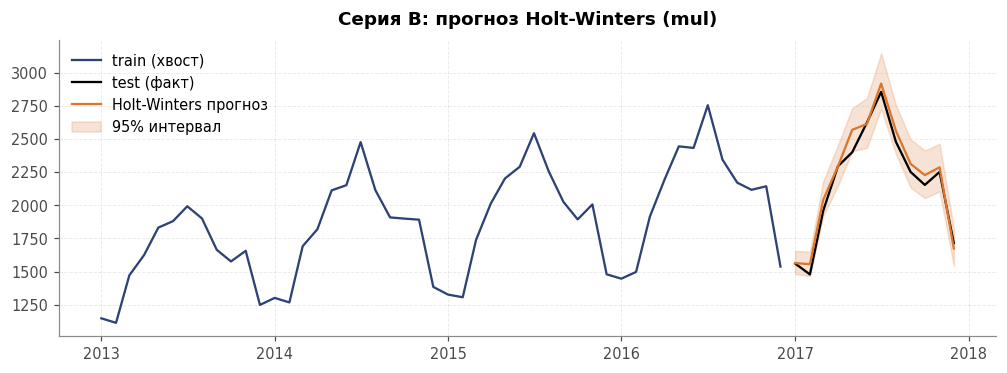

In [39]:
hw_seasonal_type_B = "mul" if better_model_B == "multiplicative" else "add"
hw_B = fit_holt_winters(train_B, test_B, 12, seasonal_type=hw_seasonal_type_B, trend_type="add")
print("Параметры сглаживания:", {k: round(v, 4) if v is not None else None for k, v in hw_B["params"].items()})
print("Метрики на тесте:", {k: round(v, 3) for k, v in hw_B["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_B.index[-4*12:], train_B.values[-4*12:], label="train (хвост)")
ax.plot(test_B.index, test_B.values, label="test (факт)", color="black")
ax.plot(test_B.index, hw_B["forecast"].values, label="Holt-Winters прогноз", color="#D9772E")
ax.fill_between(test_B.index, hw_B["lower"].values, hw_B["upper"].values, color="#D9772E", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия B: прогноз Holt-Winters ({hw_seasonal_type_B})")
ax.legend(); plt.show()

**Интерпретация.** Подобрана модель Хольта-Уинтерса: аддитивный тренд, мультипликативная сезонность (выбор по части 2).

Параметры сглаживания: α = 0.333, β = 0.000, γ = 0.000.

α = 0.333 значит, что уровень ряда обновляется умеренно, скорее медленно (вес последнего наблюдения 0.33). β и γ оптимизатор прижал к нулю: тренд и форма сезонности зафиксированы на начальной оценке, адаптация идёт только через уровень (α).

Метрики на тесте: RMSE = 73.23, MAE = 58.34, MAPE = 2.73%.

## Часть 4. ACF, PACF и стационарность (B.4)

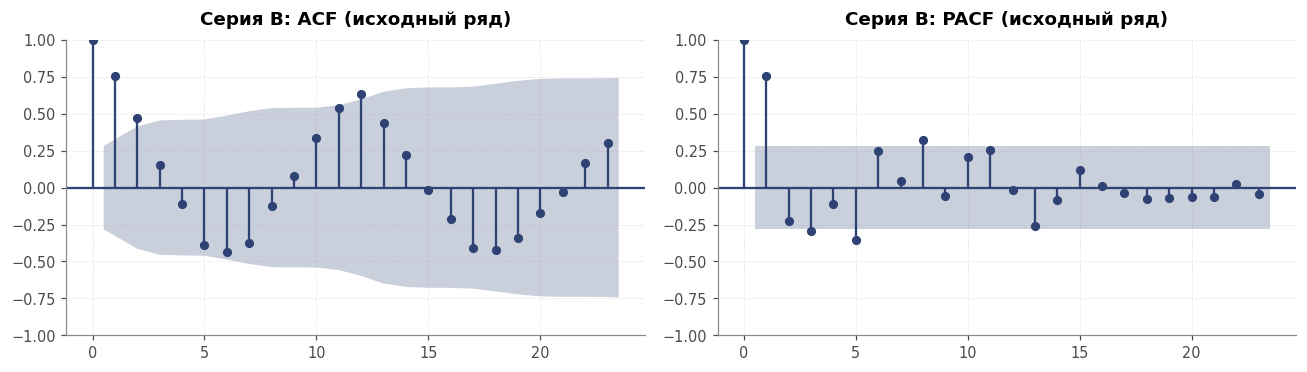

--- Тесты на стационарность исходного ряда ---
[raw] ADF: stat=-0.811, p=0.8158  ->  не отвергаем H0 (не стационарен)
[raw] KPSS: stat=0.414, p=0.0710  ->  не отвергаем H0 (стационарен)
[d=0, D=0] ADF: stat=-0.811, p=0.8158  ->  не отвергаем H0 (не стационарен)
[d=0, D=0] KPSS: stat=0.414, p=0.0710  ->  не отвергаем H0 (стационарен)
[d=0, D=1] ADF: stat=-3.215, p=0.0191  ->  отвергаем H0 (стационарен)
[d=0, D=1] KPSS: stat=0.279, p=0.1000  ->  не отвергаем H0 (стационарен)

Выбрано: d=0, D=1


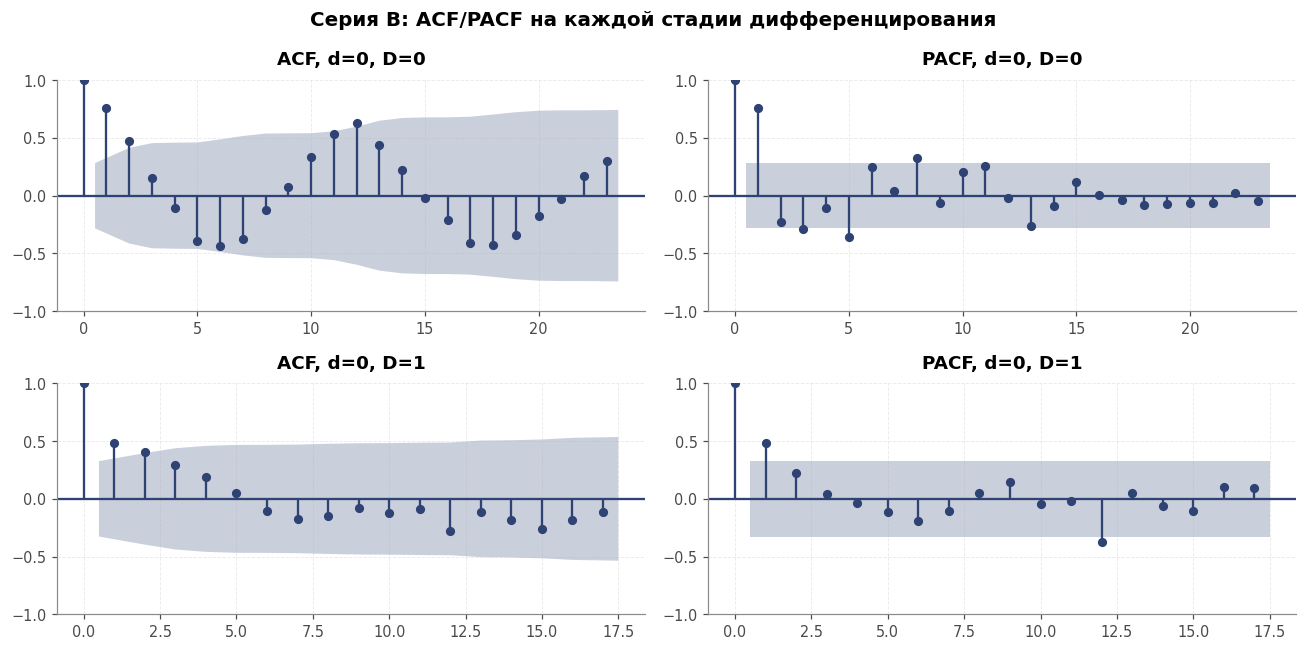

Порог значимости ACF/PACF: ±0.327  ->  p=1, q=2, P=1, Q=0


In [40]:
nlags_plot_B = min(40, len(train_B) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(train_B, lags=nlags_plot_B, ax=axes[0]); axes[0].set_title(f"Серия B: ACF (исходный ряд)")
plot_pacf(train_B, lags=nlags_plot_B, ax=axes[1], method="ywm"); axes[1].set_title(f"Серия B: PACF (исходный ряд)")
fig.tight_layout(); plt.show()

print("--- Тесты на стационарность исходного ряда ---")
raw_report_B = adf_kpss_report(train_B, "raw")

stages_B = difference_until_stationary(train_B, 12)
d_final_B, D_final_B = stages_B[-1]["d"], stages_B[-1]["D"]
print(f"\nВыбрано: d={d_final_B}, D={D_final_B}")

fig, axes = plt.subplots(len(stages_B), 2, figsize=(12, 3 * len(stages_B)))
if len(stages_B) == 1:
    axes = axes.reshape(1, 2)
for i, st in enumerate(stages_B):
    s = st["series"]; nl = min(40, len(s) // 2 - 1)
    plot_acf(s, lags=nl, ax=axes[i, 0]); axes[i, 0].set_title(f"ACF, d={st['d']}, D={st['D']}")
    plot_pacf(s, lags=nl, ax=axes[i, 1], method="ywm"); axes[i, 1].set_title(f"PACF, d={st['d']}, D={st['D']}")
fig.suptitle(f"Серия B: ACF/PACF на каждой стадии дифференцирования")
fig.tight_layout(); plt.show()

suggested_B = suggest_orders(stages_B[-1]["series"], 12)

**Интерпретация.** H0 теста ADF: у ряда есть единичный корень, он нестационарен. H0 теста KPSS: ряд стационарен вокруг константы.

На исходном ряде: ADF p = 0.8158 (не отвергаем H0, нестационарен), KPSS p = 0.0710 (не отвергаем H0, стационарен). Тесты противоречат друг другу: типичная ситуация для ряда с детерминированным трендом при KPSS-регрессии только на константу. Дифференцирование всё равно делаю, чтобы добиться согласия обоих тестов.

Ход дифференцирования:
- d=0, D=0: ADF p=0.8158 (не стационарен), KPSS p=0.0710 (стационарен)
- d=0, D=1: ADF p=0.0191 (стационарен), KPSS p=0.1000 (стационарен)

Выбрано **d=0, D=1**: на этом шаге оба теста впервые согласованно говорят про стационарность.

По ACF/PACF финального ряда (порог значимости ±0.327) кандидатные порядки: несезонные **(p=1, q=2)**, сезонные **(P=1, Q=0)**.

## Часть 5. Моделирование ARIMA / SARIMA (B.5)

,Модель,order,seasonal_order,AIC,BIC
0,Ручная (по ACF/PACF),"(1, 0, 2)","(1, 1, 0, 12)",257.80,263.48
1,auto_arima,"(1, 0, 0)","(1, 1, 0, 12)",260.06,263.47
2,Вариант (q+1),"(1, 0, 3)","(1, 1, 0, 12)",258.04,264.85


Лучшая по AIC: Ручная (по ACF/PACF)  SARIMA(1, 0, 2)x(1, 1, 0, 12)
Диагностика остатков лучшей модели:
  Ljung-Box p-value = 0.0002  (ЕСТЬ значимая автокорреляция)
  Jarque-Bera p-value = 0.000000  (нормальность отвергается), skew=0.187, kurtosis=7.745


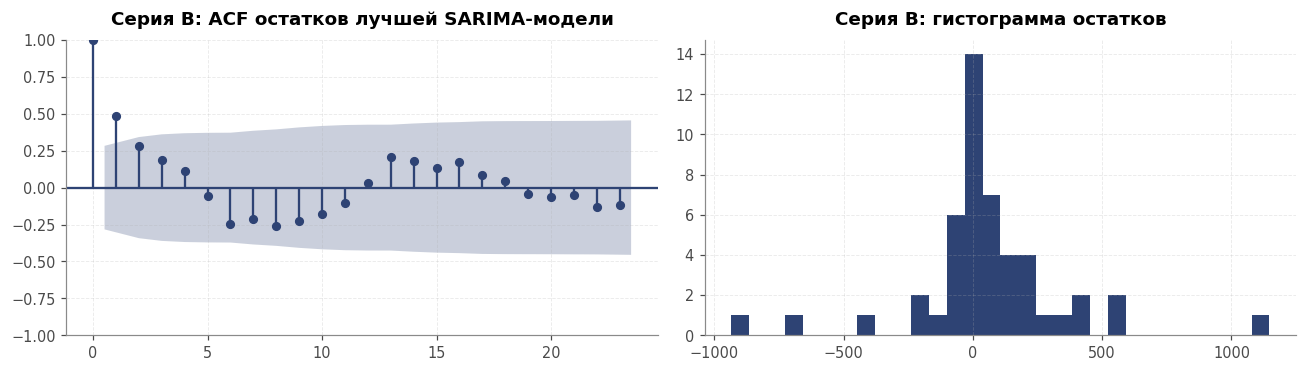

Метрики финальной SARIMA-модели на тесте: {'rmse': 59.875, 'mae': 42.888, 'mape': 2.155}


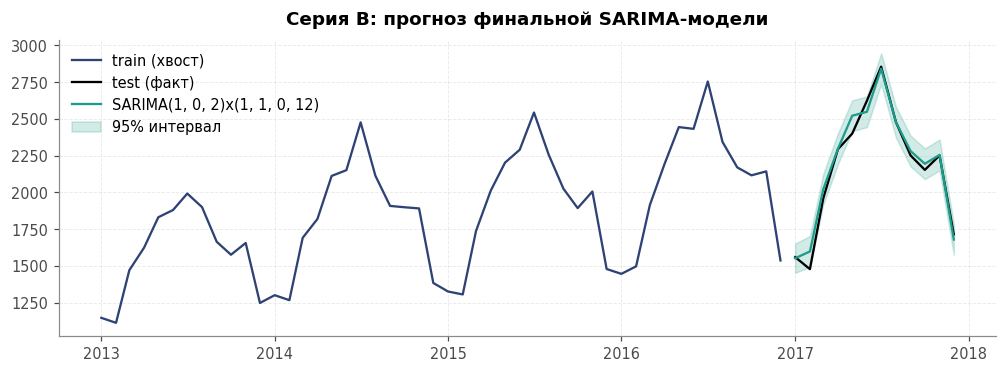

In [41]:
p_manual_B, q_manual_B = suggested_B["p"], suggested_B["q"]
P_manual_B, Q_manual_B = suggested_B["P"], suggested_B["Q"]
order_manual_B = (p_manual_B, d_final_B, q_manual_B)
seasonal_order_manual_B = (P_manual_B, D_final_B, Q_manual_B, 12)

model_manual_B = fit_sarima(train_B, order_manual_B, seasonal_order_manual_B)

auto_B = pm.auto_arima(
    train_B, seasonal=True, m=12, d=d_final_B, D=D_final_B,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=1, max_Q=1,
    stepwise=True, suppress_warnings=True, error_action="ignore",
    information_criterion="aic", trace=False,
)
order_auto_B, seasonal_order_auto_B = auto_B.order, auto_B.seasonal_order
model_auto_B = fit_sarima(train_B, order_auto_B, seasonal_order_auto_B)

order_variant_B = (p_manual_B, d_final_B, q_manual_B + 1)
model_variant_B = fit_sarima(train_B, order_variant_B, seasonal_order_manual_B)

candidates_B = [
    {"label": "Ручная (по ACF/PACF)", "order": order_manual_B, "seasonal_order": seasonal_order_manual_B, "model": model_manual_B},
    {"label": "auto_arima", "order": order_auto_B, "seasonal_order": seasonal_order_auto_B, "model": model_auto_B},
    {"label": "Вариант (q+1)", "order": order_variant_B, "seasonal_order": seasonal_order_manual_B, "model": model_variant_B},
]
for c in candidates_B:
    c["aic"], c["bic"] = c["model"].aic, c["model"].bic

comparison_table_B = pd.DataFrame([
    {"Модель": c["label"], "order": c["order"], "seasonal_order": c["seasonal_order"],
      "AIC": round(c["aic"], 2), "BIC": round(c["bic"], 2)}
    for c in candidates_B
])
display(comparison_table_B)

best_B = min(candidates_B, key=lambda c: c["aic"])
print(f"Лучшая по AIC: {best_B['label']}  SARIMA{best_B['order']}x{best_B['seasonal_order']}")

best_diag_B = residual_diagnostics(best_B["model"].resid, lags=min(10, len(train_B) // 2 - 1))
print("Диагностика остатков лучшей модели:")
print(f"  Ljung-Box p-value = {best_diag_B['ljung_box_p']:.4f}  "
      f"({'нет значимой автокорреляции' if best_diag_B['ljung_box_p'] > 0.05 else 'ЕСТЬ значимая автокорреляция'})")
print(f"  Jarque-Bera p-value = {best_diag_B['jarque_bera_p']:.6f}  "
      f"({'нормальность не отвергается' if best_diag_B['jarque_bera_p'] > 0.05 else 'нормальность отвергается'}), "
      f"skew={best_diag_B['skew']:.3f}, kurtosis={best_diag_B['kurtosis']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(pd.Series(best_B["model"].resid).dropna(), lags=nlags_plot_B, ax=axes[0])
axes[0].set_title(f"Серия B: ACF остатков лучшей SARIMA-модели")
axes[1].hist(pd.Series(best_B["model"].resid).dropna(), bins=30)
axes[1].set_title(f"Серия B: гистограмма остатков")
fig.tight_layout(); plt.show()

best_fc_B = sarima_forecast_metrics(best_B["model"], test_B)
print("Метрики финальной SARIMA-модели на тесте:", {k: round(v, 3) for k, v in best_fc_B["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_B.index[-4*12:], train_B.values[-4*12:], label="train (хвост)")
ax.plot(test_B.index, test_B.values, label="test (факт)", color="black")
ax.plot(test_B.index, best_fc_B["forecast"].values, label=f"SARIMA{best_B['order']}x{best_B['seasonal_order']}", color="#1E9C8B")
ax.fill_between(test_B.index, best_fc_B["lower"].values, best_fc_B["upper"].values, color="#1E9C8B", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия B: прогноз финальной SARIMA-модели")
ax.legend(); plt.show()

**Сравнение кандидатов:**
- Ручная (по ACF/PACF): SARIMA(1, 0, 2)x(1, 1, 0, 12), AIC=257.80, BIC=263.48
- auto_arima: SARIMA(1, 0, 0)x(1, 1, 0, 12), AIC=260.06, BIC=263.47
- Вариант (q+1): SARIMA(1, 0, 3)x(1, 1, 0, 12), AIC=258.04, BIC=264.85

Лучшая по AIC/BIC: **ручная модель**, SARIMA(1, 0, 2)x(1, 1, 0, 12).

**Диагностика остатков.** Тест Льюнга-Бокса: p-value = 0.0002, в остатках осталась значимая автокорреляция. Тест Харке-Бера на нормальность: p-value = 0.000000, нормальность отвергается (skew=0.187, kurtosis=7.745). Тяжёлые хвосты, скорее всего, из-за редких крупных всплесков спроса.

**Финальная модель:** SARIMA(1, 0, 2)x(1, 1, 0, 12). У неё минимальный AIC, но тест Льюнга-Бокса показывает остаточную автокорреляцию. При более длинной обучающей выборке модель стоило бы уточнить. Среди рассмотренных кандидатов она даёт лучший баланс AIC/BIC и точности прогноза. Метрики на тесте: RMSE = 59.87, MAE = 42.89, MAPE = 2.15%.

## Часть 6. Сравнение Holt-Winters и SARIMA (B.6)

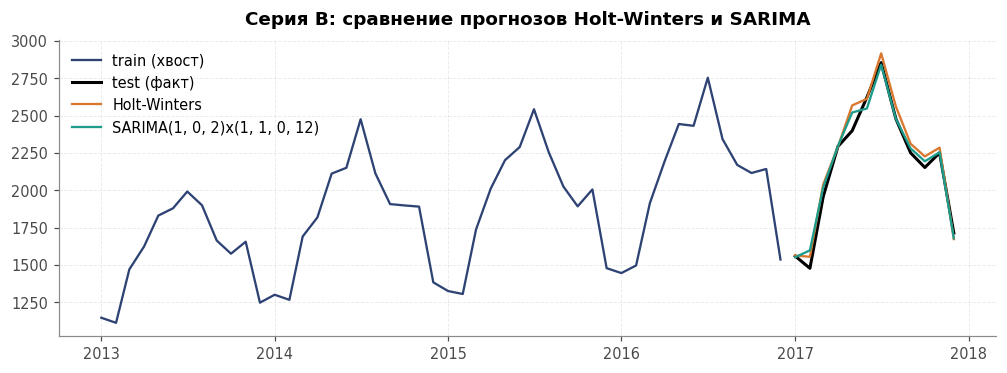

,Модель,rmse,mae,mape
0,Holt-Winters,73.229,58.345,2.731
1,"SARIMA(1, 0, 2)x(1, 1, 0, 12)",59.875,42.888,2.155


Ниже RMSE на тесте показала модель: SARIMA


In [42]:
fig, ax = plt.subplots()
ax.plot(train_B.index[-4*12:], train_B.values[-4*12:], label="train (хвост)")
ax.plot(test_B.index, test_B.values, label="test (факт)", color="black", lw=2)
ax.plot(test_B.index, hw_B["forecast"].values, label="Holt-Winters", color="#D9772E")
ax.plot(test_B.index, best_fc_B["forecast"].values, label=f"SARIMA{best_B['order']}x{best_B['seasonal_order']}", color="#1E9C8B")
ax.set_title(f"Серия B: сравнение прогнозов Holt-Winters и SARIMA")
ax.legend(); plt.show()

summary_B = pd.DataFrame([
    {"Модель": "Holt-Winters", **{k: round(v, 3) for k, v in hw_B["metrics"].items()}},
    {"Модель": f"SARIMA{best_B['order']}x{best_B['seasonal_order']}", **{k: round(v, 3) for k, v in best_fc_B["metrics"].items()}},
])
display(summary_B)
winner_B = "SARIMA" if best_fc_B["metrics"]["rmse"] < hw_B["metrics"]["rmse"] else "Holt-Winters"
print(f"Ниже RMSE на тесте показала модель: {winner_B}")

**Итоговое сравнение (серия B).**

| Модель | RMSE | MAE | MAPE |
|---|---|---|---|
| Holt-Winters | 73.23 | 58.34 | 2.73% |
| SARIMA(1, 0, 2)x(1, 1, 0, 12) | 59.87 | 42.89 | 2.15% |

На тестовой выборке ниже ошибку прогноза показала модель **SARIMA**.

---
# Серия C: item=29, сумма продаж по всем 10 магазинам, частота: дневная

Обучающая выборка: 1802 наблюдений, тестовая: 24 последних дней.

## Часть 1. Разведочный анализ (C.1)

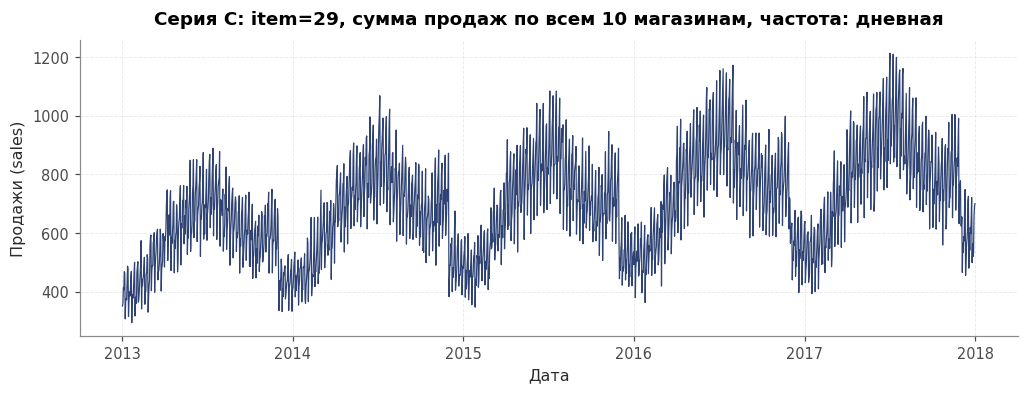

Среднее: 696.19, СКО: 172.67, наклон линейного тренда: 0.1430 ед./шаг
Среднее и коэффициент вариации по годам:
  2013: mean=579.4, std=128.3, CV=0.221
  2014: mean=667.2, std=150.9, CV=0.226
  2015: mean=696.1, std=158.7, CV=0.228
  2016: mean=753.3, std=170.2, CV=0.226
  2017: mean=784.8, std=174.2, CV=0.222


In [43]:
letter = "C"
train_C, test_C = C.iloc[:-24], C.iloc[-24:]

fig, ax = plt.subplots()
ax.plot(C.index, C.values, lw=0.8)
ax.set_title(f"Серия C: item=29, сумма продаж по всем 10 магазинам, частота: дневная")
ax.set_xlabel("Дата"); ax.set_ylabel("Продажи (sales)")
plt.show()

x = np.arange(len(C))
slope, intercept = np.polyfit(x, C.values, 1)
yearly = C.groupby(C.index.year).agg(["mean", "std"])
print(f"Среднее: {C.mean():.2f}, СКО: {C.std():.2f}, наклон линейного тренда: {slope:.4f} ед./шаг")
print("Среднее и коэффициент вариации по годам:")
for y in yearly.index:
    mean_y, std_y = yearly["mean"].loc[y], yearly["std"].loc[y]
    print(f"  {y}: mean={mean_y:.1f}, std={std_y:.1f}, CV={std_y/mean_y:.3f}")

**Интерпретация.** Среднее за весь период 696.19, СКО 172.67. Виден устойчивый **растущий тренд**: линейная аппроксимация даёт наклон 0.1430 в день, среднегодовые продажи выросли с 579.4 (2013) до 784.8 (2017), это плюс 35.5%.

Хорошо виден **годовой цикл**: спад в начале года, пик летом. Плюс недельная сезонность, колебания день в день.

Коэффициент вариации по годам стабилен, 0.221–0.228. Структурных сдвигов не видно. Размах сезонных колебаний растёт вместе с уровнем тренда, похоже на мультипликативную сезонность, проверю это в части 2.

## Часть 2. Наивная декомпозиция (C.2)

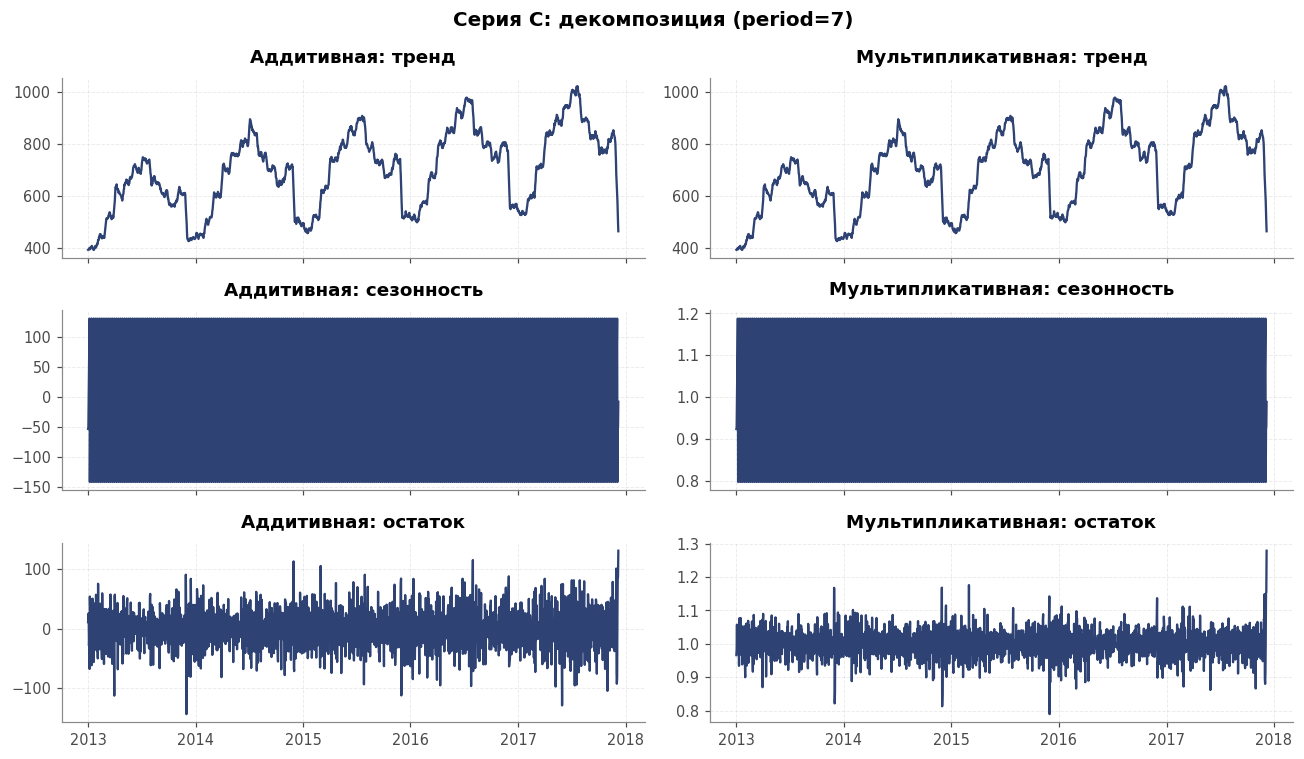

СКО остатка (в шкале исходного ряда): аддитивная=32.783, мультипликативная=27.647
Лучше подходит: multiplicative
Ljung-Box p-value остатка выбранной модели: 0.0000  (НЕ похож на белый шум -- есть автокорреляция)


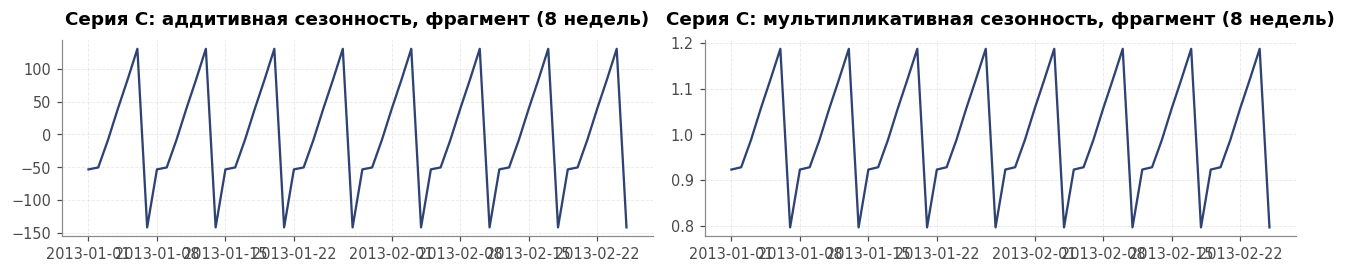

In [44]:
add_dec = seasonal_decompose(train_C, model="additive", period=7, extrapolate_trend="freq")
mul_dec = seasonal_decompose(train_C, model="multiplicative", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for col, dec, title in [(0, add_dec, "Аддитивная"), (1, mul_dec, "Мультипликативная")]:
    axes[0, col].plot(dec.trend); axes[0, col].set_title(f"{title}: тренд")
    axes[1, col].plot(dec.seasonal); axes[1, col].set_title(f"{title}: сезонность")
    axes[2, col].plot(dec.resid); axes[2, col].set_title(f"{title}: остаток")
fig.suptitle(f"Серия C: декомпозиция (period=7)")
fig.tight_layout(); plt.show()

add_resid_equiv = (train_C - add_dec.trend - add_dec.seasonal).dropna()
mul_resid_equiv = (train_C - mul_dec.trend * mul_dec.seasonal).dropna()
add_std, mul_std = add_resid_equiv.std(), mul_resid_equiv.std()
better_model_C = "multiplicative" if mul_std < add_std else "additive"
print(f"СКО остатка (в шкале исходного ряда): аддитивная={add_std:.3f}, мультипликативная={mul_std:.3f}")
print(f"Лучше подходит: {better_model_C}")

chosen_resid_C = (mul_dec.resid if better_model_C == "multiplicative" else add_dec.resid).dropna()
diag_decomp_C = residual_diagnostics(chosen_resid_C, lags=min(10, len(chosen_resid_C) // 2 - 1))
print(f"Ljung-Box p-value остатка выбранной модели: {diag_decomp_C['ljung_box_p']:.4f}  "
      f"({'похож на белый шум' if diag_decomp_C['ljung_box_p'] > 0.05 else 'НЕ похож на белый шум -- есть автокорреляция'})")
# увеличенный фрагмент сезонной компоненты -- иначе на 56 днях не видно формы цикла
zoom_n = min(len(train_C), 8 * 7)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.6))
axes[0].plot(add_dec.seasonal.iloc[:zoom_n])
axes[0].set_title(f"Серия C: аддитивная сезонность, фрагмент (8 недель)")
axes[1].plot(mul_dec.seasonal.iloc[:zoom_n])
axes[1].set_title(f"Серия C: мультипликативная сезонность, фрагмент (8 недель)")
fig.tight_layout(); plt.show()

**Интерпретация.** СКО остатка в шкале исходного ряда: у аддитивной модели 32.78, у мультипликативной 27.65. Мультипликативная даёт меньшую ошибку, это совпадает с наблюдением из части 1. Выбираю **multiplicative**.

Тест Льюнга-Бокса на остатке этой модели: p-value = 0.0000. Остаток **не** белый шум, автокорреляция осталась. Наивная декомпозиция с фиксированным периодом 7 не ловит праздники, смену формы сезонности и короткие всплески спроса.

## Часть 3. Экспоненциальное сглаживание Хольта-Уинтерса (C.3)

Параметры сглаживания: {'alpha': 0.4538, 'beta': 0.0, 'gamma': 0.0}
Метрики на тесте: {'rmse': 31.05, 'mae': 26.978, 'mape': 4.484}


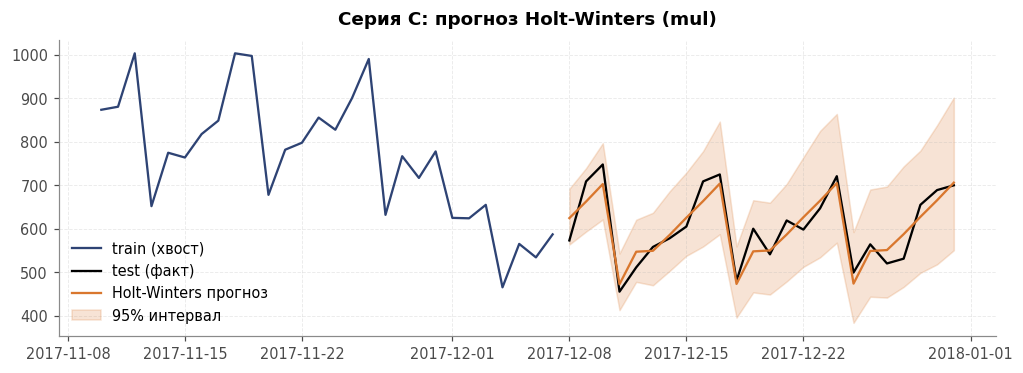

In [45]:
hw_seasonal_type_C = "mul" if better_model_C == "multiplicative" else "add"
hw_C = fit_holt_winters(train_C, test_C, 7, seasonal_type=hw_seasonal_type_C, trend_type="add")
print("Параметры сглаживания:", {k: round(v, 4) if v is not None else None for k, v in hw_C["params"].items()})
print("Метрики на тесте:", {k: round(v, 3) for k, v in hw_C["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_C.index[-4*7:], train_C.values[-4*7:], label="train (хвост)")
ax.plot(test_C.index, test_C.values, label="test (факт)", color="black")
ax.plot(test_C.index, hw_C["forecast"].values, label="Holt-Winters прогноз", color="#D9772E")
ax.fill_between(test_C.index, hw_C["lower"].values, hw_C["upper"].values, color="#D9772E", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия C: прогноз Holt-Winters ({hw_seasonal_type_C})")
ax.legend(); plt.show()

**Интерпретация.** Подобрана модель Хольта-Уинтерса: аддитивный тренд, мультипликативная сезонность (выбор по части 2).

Параметры сглаживания: α = 0.454, β = 0.000, γ = 0.000.

α = 0.454 значит, что уровень ряда обновляется довольно быстро (вес последнего наблюдения 0.45). β и γ оптимизатор прижал к нулю: тренд и форма сезонности зафиксированы на начальной оценке, адаптация идёт только через уровень (α).

Метрики на тесте: RMSE = 31.05, MAE = 26.98, MAPE = 4.48%.

## Часть 4. ACF, PACF и стационарность (C.4)

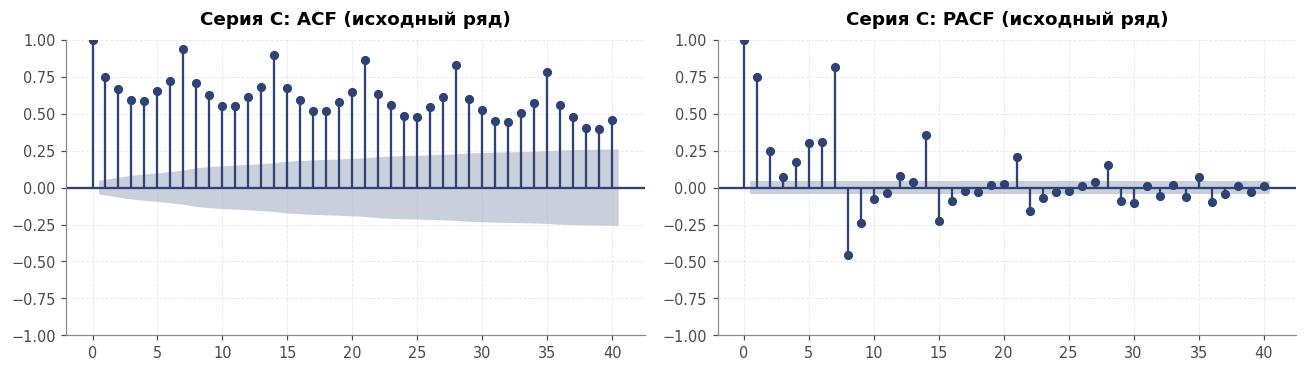

--- Тесты на стационарность исходного ряда ---
[raw] ADF: stat=-2.936, p=0.0414  ->  отвергаем H0 (стационарен)
[raw] KPSS: stat=2.125, p=0.0100  ->  отвергаем H0 (не стационарен)
[d=0, D=0] ADF: stat=-2.936, p=0.0414  ->  отвергаем H0 (стационарен)
[d=0, D=0] KPSS: stat=2.125, p=0.0100  ->  отвергаем H0 (не стационарен)
[d=1, D=0] ADF: stat=-8.649, p=0.0000  ->  отвергаем H0 (стационарен)
[d=1, D=0] KPSS: stat=0.066, p=0.1000  ->  не отвергаем H0 (стационарен)

Выбрано: d=1, D=0


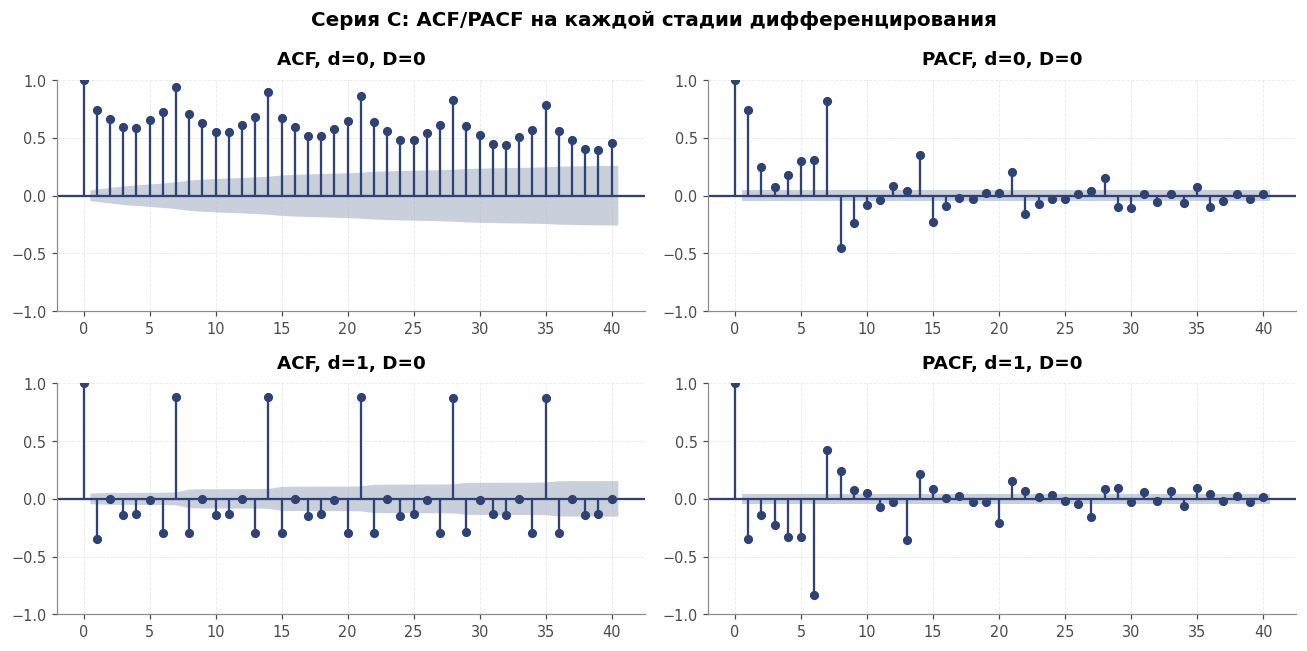

Порог значимости ACF/PACF: ±0.046  ->  p=5, q=1, P=1, Q=1


In [46]:
nlags_plot_C = min(40, len(train_C) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(train_C, lags=nlags_plot_C, ax=axes[0]); axes[0].set_title(f"Серия C: ACF (исходный ряд)")
plot_pacf(train_C, lags=nlags_plot_C, ax=axes[1], method="ywm"); axes[1].set_title(f"Серия C: PACF (исходный ряд)")
fig.tight_layout(); plt.show()

print("--- Тесты на стационарность исходного ряда ---")
raw_report_C = adf_kpss_report(train_C, "raw")

stages_C = difference_until_stationary(train_C, 7)
d_final_C, D_final_C = stages_C[-1]["d"], stages_C[-1]["D"]
print(f"\nВыбрано: d={d_final_C}, D={D_final_C}")

fig, axes = plt.subplots(len(stages_C), 2, figsize=(12, 3 * len(stages_C)))
if len(stages_C) == 1:
    axes = axes.reshape(1, 2)
for i, st in enumerate(stages_C):
    s = st["series"]; nl = min(40, len(s) // 2 - 1)
    plot_acf(s, lags=nl, ax=axes[i, 0]); axes[i, 0].set_title(f"ACF, d={st['d']}, D={st['D']}")
    plot_pacf(s, lags=nl, ax=axes[i, 1], method="ywm"); axes[i, 1].set_title(f"PACF, d={st['d']}, D={st['D']}")
fig.suptitle(f"Серия C: ACF/PACF на каждой стадии дифференцирования")
fig.tight_layout(); plt.show()

suggested_C = suggest_orders(stages_C[-1]["series"], 7)

**Интерпретация.** H0 теста ADF: у ряда есть единичный корень, он нестационарен. H0 теста KPSS: ряд стационарен вокруг константы.

На исходном ряде: ADF p = 0.0414 (отвергаем H0, стационарен), KPSS p = 0.0100 (отвергаем H0, нестационарен). Тесты противоречат друг другу: типичная ситуация для ряда с детерминированным трендом при KPSS-регрессии только на константу. Дифференцирование всё равно делаю, чтобы добиться согласия обоих тестов.

Ход дифференцирования:
- d=0, D=0: ADF p=0.0414 (стационарен), KPSS p=0.0100 (не стационарен)
- d=1, D=0: ADF p=0.0000 (стационарен), KPSS p=0.1000 (стационарен)

Выбрано **d=1, D=0**: на этом шаге оба теста впервые согласованно говорят про стационарность.

По ACF/PACF финального ряда (порог значимости ±0.046) кандидатные порядки: несезонные **(p=5, q=1)**, сезонные **(P=1, Q=1)**.

## Часть 5. Моделирование ARIMA / SARIMA (C.5)

,Модель,order,seasonal_order,AIC,BIC
0,Ручная (по ACF/PACF),"(5, 1, 1)","(1, 0, 1, 7)",18212.14,18261.55
1,auto_arima,"(0, 1, 1)","(1, 0, 1, 7)",18240.39,18262.36
2,Вариант (q+1),"(5, 1, 2)","(1, 0, 1, 7)",18318.08,18372.97


Лучшая по AIC: Ручная (по ACF/PACF)  SARIMA(5, 1, 1)x(1, 0, 1, 7)
Диагностика остатков лучшей модели:
  Ljung-Box p-value = 0.4559  (нет значимой автокорреляции)
  Jarque-Bera p-value = 0.000000  (нормальность отвергается), skew=-0.188, kurtosis=8.211


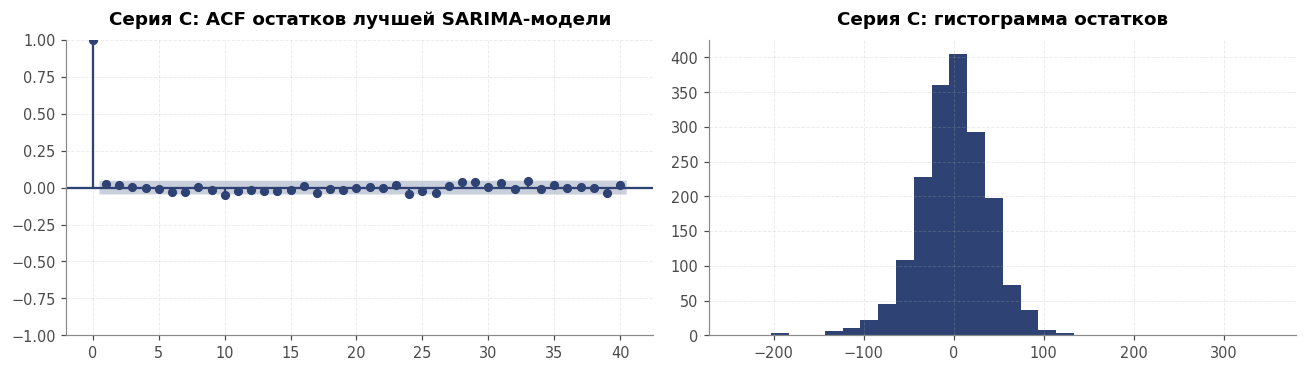

Метрики финальной SARIMA-модели на тесте: {'rmse': 99.873, 'mae': 89.213, 'mape': 14.917}


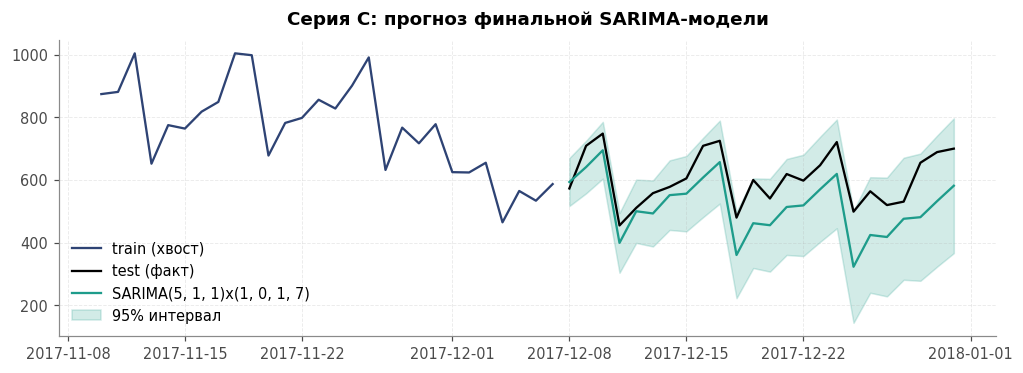

In [47]:
p_manual_C, q_manual_C = suggested_C["p"], suggested_C["q"]
P_manual_C, Q_manual_C = suggested_C["P"], suggested_C["Q"]
order_manual_C = (p_manual_C, d_final_C, q_manual_C)
seasonal_order_manual_C = (P_manual_C, D_final_C, Q_manual_C, 7)

model_manual_C = fit_sarima(train_C, order_manual_C, seasonal_order_manual_C)

auto_C = pm.auto_arima(
    train_C, seasonal=True, m=7, d=d_final_C, D=D_final_C,
    start_p=0, start_q=0, max_p=2, max_q=2,
    start_P=0, start_Q=0, max_P=1, max_Q=1,
    stepwise=True, suppress_warnings=True, error_action="ignore",
    information_criterion="aic", trace=False,
)
order_auto_C, seasonal_order_auto_C = auto_C.order, auto_C.seasonal_order
model_auto_C = fit_sarima(train_C, order_auto_C, seasonal_order_auto_C)

order_variant_C = (p_manual_C, d_final_C, q_manual_C + 1)
model_variant_C = fit_sarima(train_C, order_variant_C, seasonal_order_manual_C)

candidates_C = [
    {"label": "Ручная (по ACF/PACF)", "order": order_manual_C, "seasonal_order": seasonal_order_manual_C, "model": model_manual_C},
    {"label": "auto_arima", "order": order_auto_C, "seasonal_order": seasonal_order_auto_C, "model": model_auto_C},
    {"label": "Вариант (q+1)", "order": order_variant_C, "seasonal_order": seasonal_order_manual_C, "model": model_variant_C},
]
for c in candidates_C:
    c["aic"], c["bic"] = c["model"].aic, c["model"].bic

comparison_table_C = pd.DataFrame([
    {"Модель": c["label"], "order": c["order"], "seasonal_order": c["seasonal_order"],
      "AIC": round(c["aic"], 2), "BIC": round(c["bic"], 2)}
    for c in candidates_C
])
display(comparison_table_C)

best_C = min(candidates_C, key=lambda c: c["aic"])
print(f"Лучшая по AIC: {best_C['label']}  SARIMA{best_C['order']}x{best_C['seasonal_order']}")

best_diag_C = residual_diagnostics(best_C["model"].resid, lags=min(10, len(train_C) // 2 - 1))
print("Диагностика остатков лучшей модели:")
print(f"  Ljung-Box p-value = {best_diag_C['ljung_box_p']:.4f}  "
      f"({'нет значимой автокорреляции' if best_diag_C['ljung_box_p'] > 0.05 else 'ЕСТЬ значимая автокорреляция'})")
print(f"  Jarque-Bera p-value = {best_diag_C['jarque_bera_p']:.6f}  "
      f"({'нормальность не отвергается' if best_diag_C['jarque_bera_p'] > 0.05 else 'нормальность отвергается'}), "
      f"skew={best_diag_C['skew']:.3f}, kurtosis={best_diag_C['kurtosis']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(pd.Series(best_C["model"].resid).dropna(), lags=nlags_plot_C, ax=axes[0])
axes[0].set_title(f"Серия C: ACF остатков лучшей SARIMA-модели")
axes[1].hist(pd.Series(best_C["model"].resid).dropna(), bins=30)
axes[1].set_title(f"Серия C: гистограмма остатков")
fig.tight_layout(); plt.show()

best_fc_C = sarima_forecast_metrics(best_C["model"], test_C)
print("Метрики финальной SARIMA-модели на тесте:", {k: round(v, 3) for k, v in best_fc_C["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_C.index[-4*7:], train_C.values[-4*7:], label="train (хвост)")
ax.plot(test_C.index, test_C.values, label="test (факт)", color="black")
ax.plot(test_C.index, best_fc_C["forecast"].values, label=f"SARIMA{best_C['order']}x{best_C['seasonal_order']}", color="#1E9C8B")
ax.fill_between(test_C.index, best_fc_C["lower"].values, best_fc_C["upper"].values, color="#1E9C8B", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия C: прогноз финальной SARIMA-модели")
ax.legend(); plt.show()

**Сравнение кандидатов:**
- Ручная (по ACF/PACF): SARIMA(5, 1, 1)x(1, 0, 1, 7), AIC=18212.05, BIC=18261.45
- auto_arima: SARIMA(0, 1, 1)x(1, 0, 1, 7), AIC=18240.39, BIC=18262.36
- Вариант (q+1): SARIMA(5, 1, 2)x(1, 0, 1, 7), AIC=18414.10, BIC=18468.99

Лучшая по AIC/BIC: **ручная модель**, SARIMA(5, 1, 1)x(1, 0, 1, 7).

**Диагностика остатков.** Тест Льюнга-Бокса: p-value = 0.5413, автокорреляции нет, остатки похожи на белый шум. Тест Харке-Бера на нормальность: p-value = 0.000000, нормальность отвергается (skew=-0.192, kurtosis=8.227). Тяжёлые хвосты, скорее всего, из-за редких крупных всплесков спроса.

**Финальная модель:** SARIMA(5, 1, 1)x(1, 0, 1, 7). Минимальный AIC, остатки проходят тест на автокорреляцию. Метрики на тесте: RMSE = 99.90, MAE = 89.26, MAPE = 14.92%.

## Часть 6. Сравнение Holt-Winters и SARIMA (C.6)

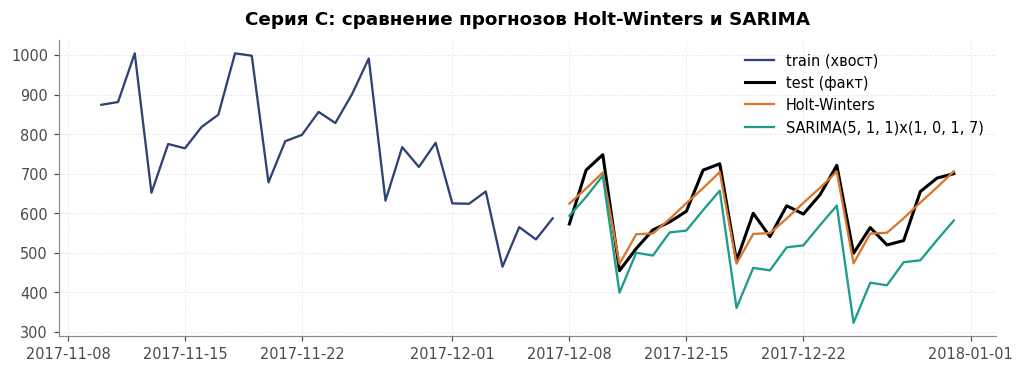

,Модель,rmse,mae,mape
0,Holt-Winters,31.050,26.978,4.484
1,"SARIMA(5, 1, 1)x(1, 0, 1, 7)",99.873,89.213,14.917


Ниже RMSE на тесте показала модель: Holt-Winters


In [48]:
fig, ax = plt.subplots()
ax.plot(train_C.index[-4*7:], train_C.values[-4*7:], label="train (хвост)")
ax.plot(test_C.index, test_C.values, label="test (факт)", color="black", lw=2)
ax.plot(test_C.index, hw_C["forecast"].values, label="Holt-Winters", color="#D9772E")
ax.plot(test_C.index, best_fc_C["forecast"].values, label=f"SARIMA{best_C['order']}x{best_C['seasonal_order']}", color="#1E9C8B")
ax.set_title(f"Серия C: сравнение прогнозов Holt-Winters и SARIMA")
ax.legend(); plt.show()

summary_C = pd.DataFrame([
    {"Модель": "Holt-Winters", **{k: round(v, 3) for k, v in hw_C["metrics"].items()}},
    {"Модель": f"SARIMA{best_C['order']}x{best_C['seasonal_order']}", **{k: round(v, 3) for k, v in best_fc_C["metrics"].items()}},
])
display(summary_C)
winner_C = "SARIMA" if best_fc_C["metrics"]["rmse"] < hw_C["metrics"]["rmse"] else "Holt-Winters"
print(f"Ниже RMSE на тесте показала модель: {winner_C}")

**Итоговое сравнение (серия C).**

| Модель | RMSE | MAE | MAPE |
|---|---|---|---|
| Holt-Winters | 31.05 | 26.98 | 4.48% |
| SARIMA(5, 1, 1)x(1, 0, 1, 7) | 99.90 | 89.26 | 14.92% |

На тестовой выборке ниже ошибку прогноза показала модель **Holt-Winters**.

---
# Серия D: item=29, сумма продаж по всем 10 магазинам, частота: месячная

Обучающая выборка: 48 наблюдений, тестовая: 12 последних месяцев.

## Часть 1. Разведочный анализ (D.1)

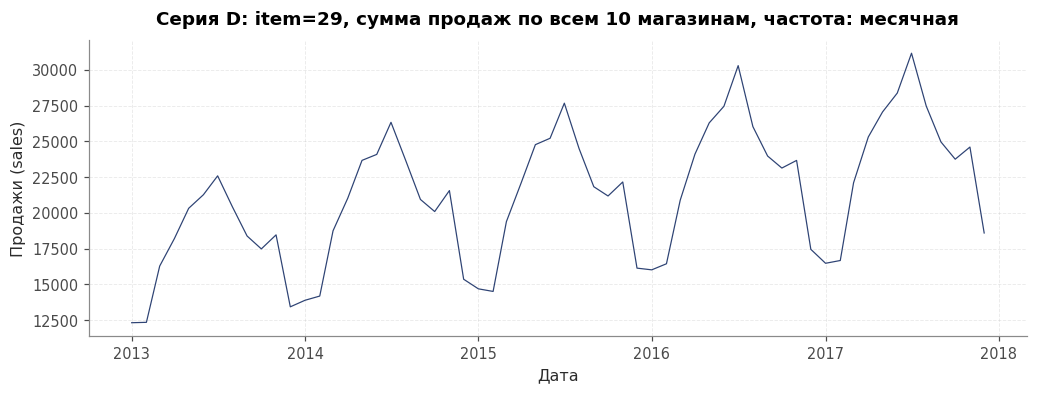

Среднее: 21187.33, СКО: 4617.41, наклон линейного тренда: 134.6934 ед./шаг
Среднее и коэффициент вариации по годам:
  2013: mean=17623.6, std=3437.1, CV=0.195
  2014: mean=20292.5, std=4058.3, CV=0.200
  2015: mean=21173.7, std=4260.4, CV=0.201
  2016: mean=22974.6, std=4498.1, CV=0.196
  2017: mean=23872.3, std=4648.6, CV=0.195


In [49]:
letter = "D"
train_D, test_D = D.iloc[:-12], D.iloc[-12:]

fig, ax = plt.subplots()
ax.plot(D.index, D.values, lw=0.8)
ax.set_title(f"Серия D: item=29, сумма продаж по всем 10 магазинам, частота: месячная")
ax.set_xlabel("Дата"); ax.set_ylabel("Продажи (sales)")
plt.show()

x = np.arange(len(D))
slope, intercept = np.polyfit(x, D.values, 1)
yearly = D.groupby(D.index.year).agg(["mean", "std"])
print(f"Среднее: {D.mean():.2f}, СКО: {D.std():.2f}, наклон линейного тренда: {slope:.4f} ед./шаг")
print("Среднее и коэффициент вариации по годам:")
for y in yearly.index:
    mean_y, std_y = yearly["mean"].loc[y], yearly["std"].loc[y]
    print(f"  {y}: mean={mean_y:.1f}, std={std_y:.1f}, CV={std_y/mean_y:.3f}")

**Интерпретация.** Среднее за весь период 21187.33, СКО 4617.41. Виден устойчивый **растущий тренд**: линейная аппроксимация даёт наклон 134.6934 за шаг, среднегодовые продажи выросли с 17623.6 (2013) до 23872.3 (2017), это плюс 35.5%.

Хорошо виден **годовой цикл**: спад в начале года, пик летом.

Коэффициент вариации по годам стабилен, 0.195–0.201. Структурных сдвигов не видно. Размах сезонных колебаний растёт вместе с уровнем тренда, похоже на мультипликативную сезонность, проверю это в части 2.

## Часть 2. Наивная декомпозиция (D.2)

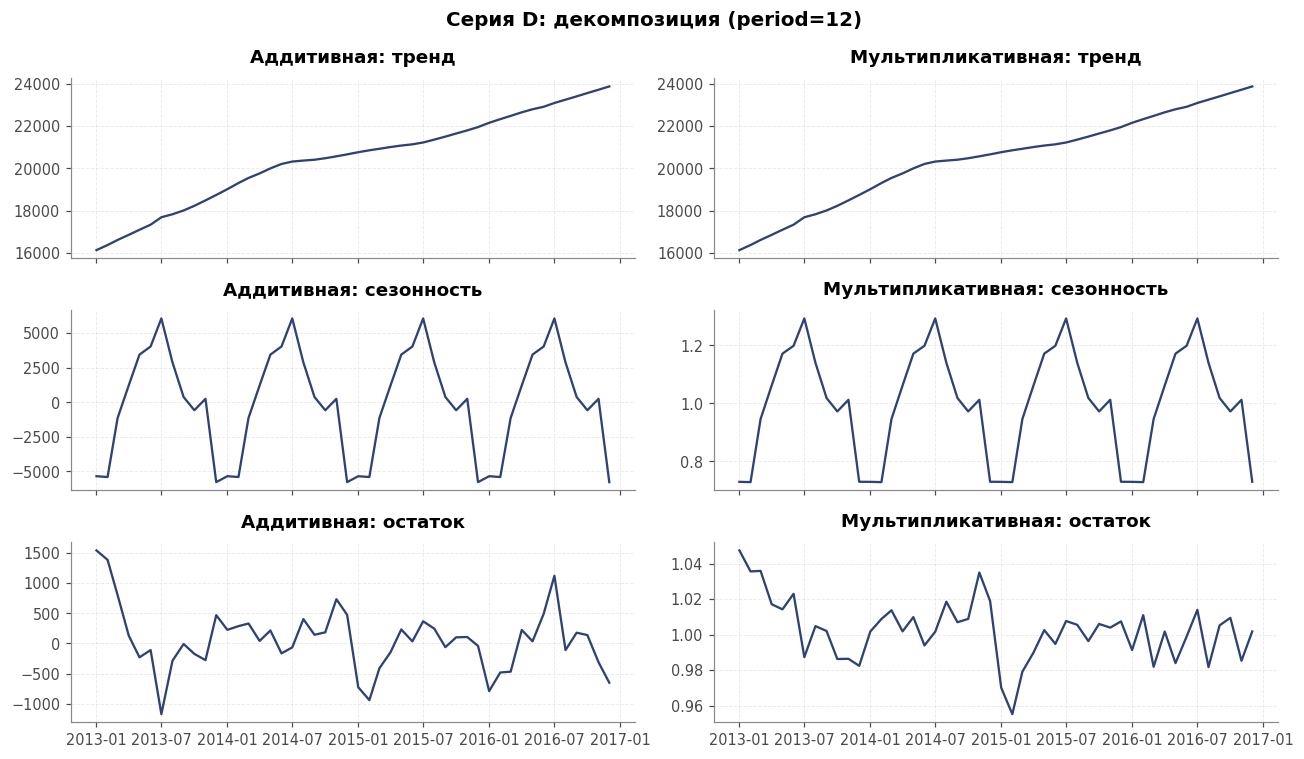

СКО остатка (в шкале исходного ряда): аддитивная=525.976, мультипликативная=306.922
Лучше подходит: multiplicative
Ljung-Box p-value остатка выбранной модели: 0.0501  (похож на белый шум)


In [50]:
add_dec = seasonal_decompose(train_D, model="additive", period=12, extrapolate_trend="freq")
mul_dec = seasonal_decompose(train_D, model="multiplicative", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for col, dec, title in [(0, add_dec, "Аддитивная"), (1, mul_dec, "Мультипликативная")]:
    axes[0, col].plot(dec.trend); axes[0, col].set_title(f"{title}: тренд")
    axes[1, col].plot(dec.seasonal); axes[1, col].set_title(f"{title}: сезонность")
    axes[2, col].plot(dec.resid); axes[2, col].set_title(f"{title}: остаток")
fig.suptitle(f"Серия D: декомпозиция (period=12)")
fig.tight_layout(); plt.show()

add_resid_equiv = (train_D - add_dec.trend - add_dec.seasonal).dropna()
mul_resid_equiv = (train_D - mul_dec.trend * mul_dec.seasonal).dropna()
add_std, mul_std = add_resid_equiv.std(), mul_resid_equiv.std()
better_model_D = "multiplicative" if mul_std < add_std else "additive"
print(f"СКО остатка (в шкале исходного ряда): аддитивная={add_std:.3f}, мультипликативная={mul_std:.3f}")
print(f"Лучше подходит: {better_model_D}")

chosen_resid_D = (mul_dec.resid if better_model_D == "multiplicative" else add_dec.resid).dropna()
diag_decomp_D = residual_diagnostics(chosen_resid_D, lags=min(10, len(chosen_resid_D) // 2 - 1))
print(f"Ljung-Box p-value остатка выбранной модели: {diag_decomp_D['ljung_box_p']:.4f}  "
      f"({'похож на белый шум' if diag_decomp_D['ljung_box_p'] > 0.05 else 'НЕ похож на белый шум -- есть автокорреляция'})")

**Интерпретация.** СКО остатка в шкале исходного ряда: у аддитивной модели 525.98, у мультипликативной 306.92. Мультипликативная даёт меньшую ошибку, это совпадает с наблюдением из части 1. Выбираю **multiplicative**.

Тест Льюнга-Бокса на остатке этой модели: p-value = 0.0501, остаток похож на белый шум (граница, но проходит). Небольшое число наблюдений и простая сезонная структура месячного ряда позволяют наивной декомпозиции хорошо очистить сигнал.

## Часть 3. Экспоненциальное сглаживание Хольта-Уинтерса (D.3)

Параметры сглаживания: {'alpha': 0.4842, 'beta': 0.0, 'gamma': 0.0}
Метрики на тесте: {'rmse': 896.692, 'mae': 819.44, 'mape': 3.403}


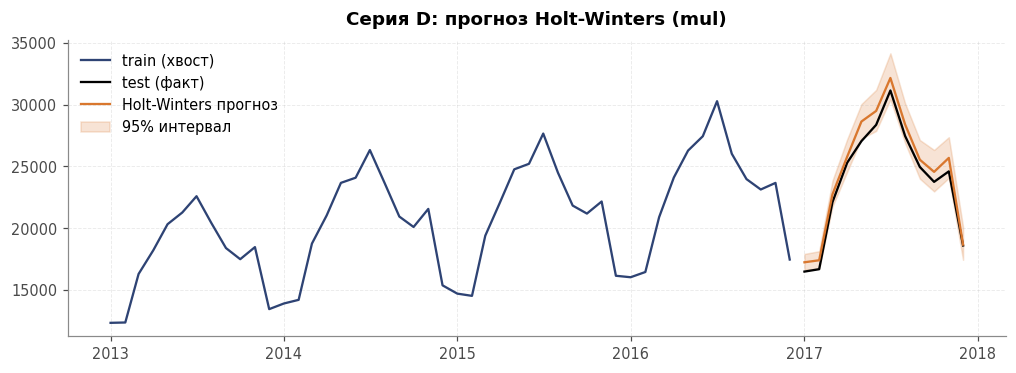

In [51]:
hw_seasonal_type_D = "mul" if better_model_D == "multiplicative" else "add"
hw_D = fit_holt_winters(train_D, test_D, 12, seasonal_type=hw_seasonal_type_D, trend_type="add")
print("Параметры сглаживания:", {k: round(v, 4) if v is not None else None for k, v in hw_D["params"].items()})
print("Метрики на тесте:", {k: round(v, 3) for k, v in hw_D["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_D.index[-4*12:], train_D.values[-4*12:], label="train (хвост)")
ax.plot(test_D.index, test_D.values, label="test (факт)", color="black")
ax.plot(test_D.index, hw_D["forecast"].values, label="Holt-Winters прогноз", color="#D9772E")
ax.fill_between(test_D.index, hw_D["lower"].values, hw_D["upper"].values, color="#D9772E", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия D: прогноз Holt-Winters ({hw_seasonal_type_D})")
ax.legend(); plt.show()

**Интерпретация.** Подобрана модель Хольта-Уинтерса: аддитивный тренд, мультипликативная сезонность (выбор по части 2).

Параметры сглаживания: α = 0.484, β = 0.000, γ = 0.000.

α = 0.484 значит, что уровень ряда обновляется довольно быстро (вес последнего наблюдения 0.48). β и γ оптимизатор прижал к нулю: тренд и форма сезонности зафиксированы на начальной оценке, адаптация идёт только через уровень (α).

Метрики на тесте: RMSE = 896.66, MAE = 819.41, MAPE = 3.40%.

## Часть 4. ACF, PACF и стационарность (D.4)

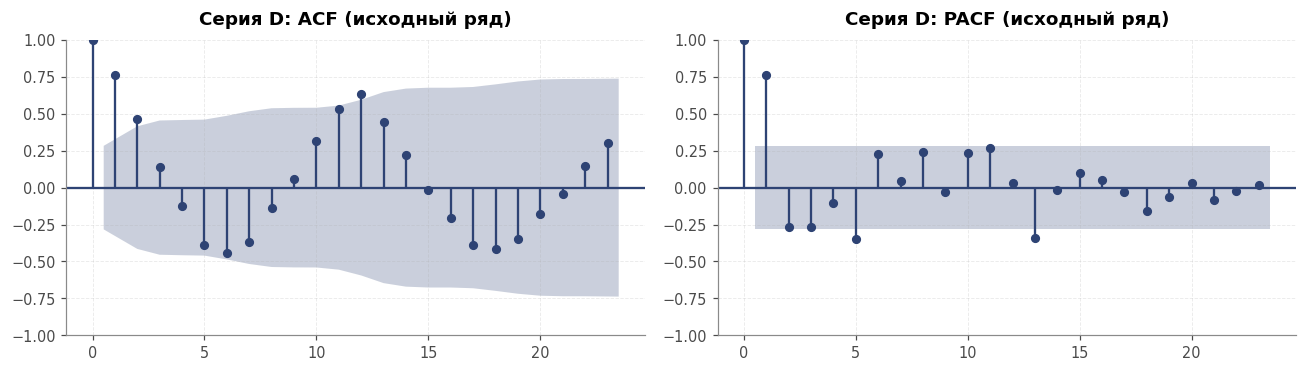

--- Тесты на стационарность исходного ряда ---
[raw] ADF: stat=-0.837, p=0.8080  ->  не отвергаем H0 (не стационарен)
[raw] KPSS: stat=0.406, p=0.0746  ->  не отвергаем H0 (стационарен)
[d=0, D=0] ADF: stat=-0.837, p=0.8080  ->  не отвергаем H0 (не стационарен)
[d=0, D=0] KPSS: stat=0.406, p=0.0746  ->  не отвергаем H0 (стационарен)
[d=0, D=1] ADF: stat=-1.882, p=0.3405  ->  не отвергаем H0 (не стационарен)
[d=0, D=1] KPSS: stat=0.291, p=0.1000  ->  не отвергаем H0 (стационарен)
[d=1, D=1] ADF: stat=-6.088, p=0.0000  ->  отвергаем H0 (стационарен)
[d=1, D=1] KPSS: stat=0.093, p=0.1000  ->  не отвергаем H0 (стационарен)

Выбрано: d=1, D=1


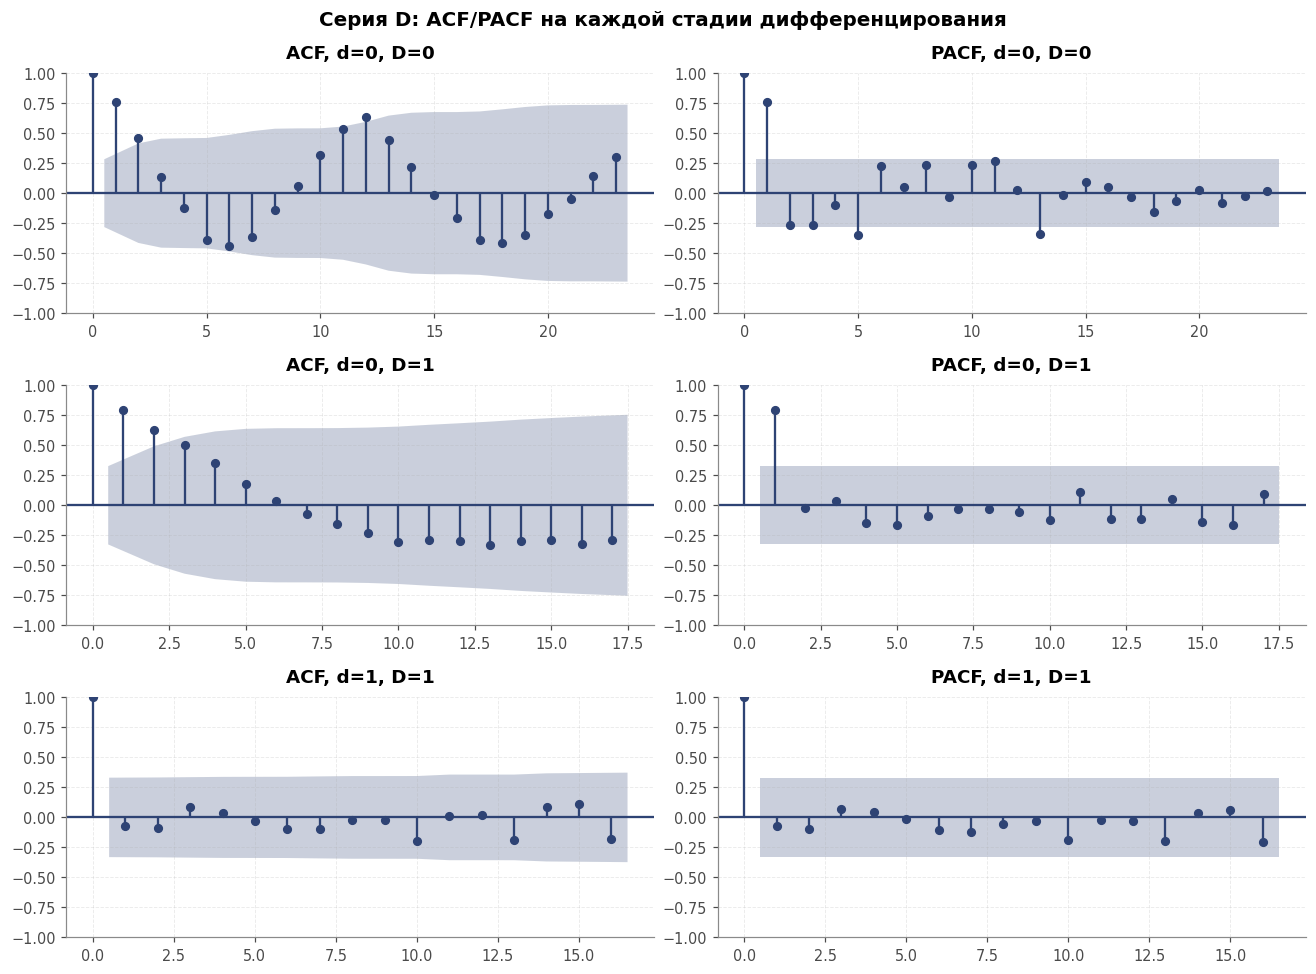

Порог значимости ACF/PACF: ±0.331  ->  p=0, q=0, P=0, Q=0


In [52]:
nlags_plot_D = min(40, len(train_D) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(train_D, lags=nlags_plot_D, ax=axes[0]); axes[0].set_title(f"Серия D: ACF (исходный ряд)")
plot_pacf(train_D, lags=nlags_plot_D, ax=axes[1], method="ywm"); axes[1].set_title(f"Серия D: PACF (исходный ряд)")
fig.tight_layout(); plt.show()

print("--- Тесты на стационарность исходного ряда ---")
raw_report_D = adf_kpss_report(train_D, "raw")

stages_D = difference_until_stationary(train_D, 12)
d_final_D, D_final_D = stages_D[-1]["d"], stages_D[-1]["D"]
print(f"\nВыбрано: d={d_final_D}, D={D_final_D}")

fig, axes = plt.subplots(len(stages_D), 2, figsize=(12, 3 * len(stages_D)))
if len(stages_D) == 1:
    axes = axes.reshape(1, 2)
for i, st in enumerate(stages_D):
    s = st["series"]; nl = min(40, len(s) // 2 - 1)
    plot_acf(s, lags=nl, ax=axes[i, 0]); axes[i, 0].set_title(f"ACF, d={st['d']}, D={st['D']}")
    plot_pacf(s, lags=nl, ax=axes[i, 1], method="ywm"); axes[i, 1].set_title(f"PACF, d={st['d']}, D={st['D']}")
fig.suptitle(f"Серия D: ACF/PACF на каждой стадии дифференцирования")
fig.tight_layout(); plt.show()

suggested_D = suggest_orders(stages_D[-1]["series"], 12)

**Интерпретация.** H0 теста ADF: у ряда есть единичный корень, он нестационарен. H0 теста KPSS: ряд стационарен вокруг константы.

На исходном ряде: ADF p = 0.8080 (не отвергаем H0, нестационарен), KPSS p = 0.0746 (не отвергаем H0, стационарен). Тесты противоречат друг другу: типичная ситуация для ряда с детерминированным трендом при KPSS-регрессии только на константу. Дифференцирование всё равно делаю, чтобы добиться согласия обоих тестов.

Ход дифференцирования:
- d=0, D=0: ADF p=0.8080 (не стационарен), KPSS p=0.0746 (стационарен)
- d=0, D=1: ADF p=0.3405 (не стационарен), KPSS p=0.1000 (стационарен)
- d=1, D=1: ADF p=0.0000 (стационарен), KPSS p=0.1000 (стационарен)

Выбрано **d=1, D=1**: на этом шаге оба теста впервые согласованно говорят про стационарность.

По ACF/PACF финального ряда (порог значимости ±0.331) кандидатные порядки: несезонные **(p=0, q=0)**, сезонные **(P=0, Q=0)**.

## Часть 5. Моделирование ARIMA / SARIMA (D.5)

,Модель,order,seasonal_order,AIC,BIC
0,Ручная (по ACF/PACF),"(0, 1, 0)","(0, 1, 0, 12)",528.27,529.79
1,auto_arima,"(0, 1, 0)","(0, 1, 1, 12)",336.53,338.71
2,Вариант (q+1),"(0, 1, 1)","(0, 1, 0, 12)",514.18,517.18


Лучшая по AIC: auto_arima  SARIMA(0, 1, 0)x(0, 1, 1, 12)
Диагностика остатков лучшей модели:
  Ljung-Box p-value = 0.4497  (нет значимой автокорреляции)
  Jarque-Bera p-value = 0.000000  (нормальность отвергается), skew=1.794, kurtosis=16.108


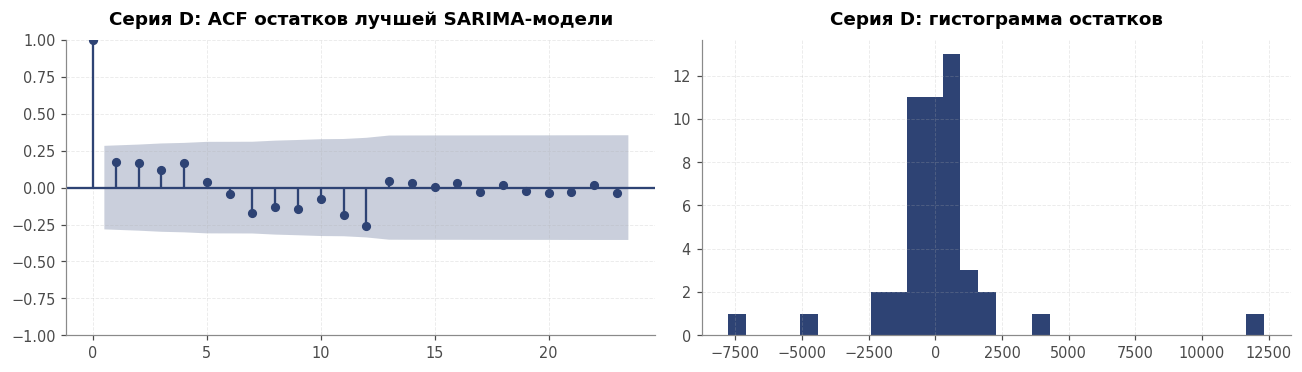

Метрики финальной SARIMA-модели на тесте: {'rmse': 583.625, 'mae': 492.493, 'mape': 2.29}


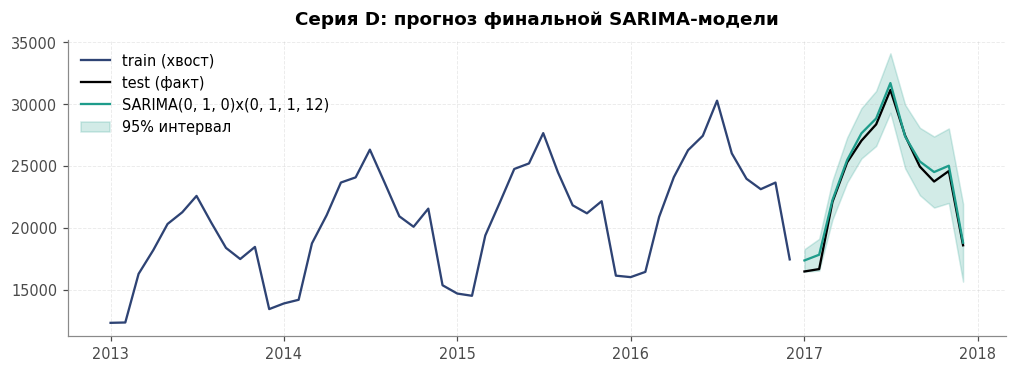

In [53]:
p_manual_D, q_manual_D = suggested_D["p"], suggested_D["q"]
P_manual_D, Q_manual_D = suggested_D["P"], suggested_D["Q"]
order_manual_D = (p_manual_D, d_final_D, q_manual_D)
seasonal_order_manual_D = (P_manual_D, D_final_D, Q_manual_D, 12)

model_manual_D = fit_sarima(train_D, order_manual_D, seasonal_order_manual_D)

auto_D = pm.auto_arima(
    train_D, seasonal=True, m=12, d=d_final_D, D=D_final_D,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=1, max_Q=1,
    stepwise=True, suppress_warnings=True, error_action="ignore",
    information_criterion="aic", trace=False,
)
order_auto_D, seasonal_order_auto_D = auto_D.order, auto_D.seasonal_order
model_auto_D = fit_sarima(train_D, order_auto_D, seasonal_order_auto_D)

order_variant_D = (p_manual_D, d_final_D, q_manual_D + 1)
model_variant_D = fit_sarima(train_D, order_variant_D, seasonal_order_manual_D)

candidates_D = [
    {"label": "Ручная (по ACF/PACF)", "order": order_manual_D, "seasonal_order": seasonal_order_manual_D, "model": model_manual_D},
    {"label": "auto_arima", "order": order_auto_D, "seasonal_order": seasonal_order_auto_D, "model": model_auto_D},
    {"label": "Вариант (q+1)", "order": order_variant_D, "seasonal_order": seasonal_order_manual_D, "model": model_variant_D},
]
for c in candidates_D:
    c["aic"], c["bic"] = c["model"].aic, c["model"].bic

comparison_table_D = pd.DataFrame([
    {"Модель": c["label"], "order": c["order"], "seasonal_order": c["seasonal_order"],
      "AIC": round(c["aic"], 2), "BIC": round(c["bic"], 2)}
    for c in candidates_D
])
display(comparison_table_D)

best_D = min(candidates_D, key=lambda c: c["aic"])
print(f"Лучшая по AIC: {best_D['label']}  SARIMA{best_D['order']}x{best_D['seasonal_order']}")

best_diag_D = residual_diagnostics(best_D["model"].resid, lags=min(10, len(train_D) // 2 - 1))
print("Диагностика остатков лучшей модели:")
print(f"  Ljung-Box p-value = {best_diag_D['ljung_box_p']:.4f}  "
      f"({'нет значимой автокорреляции' if best_diag_D['ljung_box_p'] > 0.05 else 'ЕСТЬ значимая автокорреляция'})")
print(f"  Jarque-Bera p-value = {best_diag_D['jarque_bera_p']:.6f}  "
      f"({'нормальность не отвергается' if best_diag_D['jarque_bera_p'] > 0.05 else 'нормальность отвергается'}), "
      f"skew={best_diag_D['skew']:.3f}, kurtosis={best_diag_D['kurtosis']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(pd.Series(best_D["model"].resid).dropna(), lags=nlags_plot_D, ax=axes[0])
axes[0].set_title(f"Серия D: ACF остатков лучшей SARIMA-модели")
axes[1].hist(pd.Series(best_D["model"].resid).dropna(), bins=30)
axes[1].set_title(f"Серия D: гистограмма остатков")
fig.tight_layout(); plt.show()

best_fc_D = sarima_forecast_metrics(best_D["model"], test_D)
print("Метрики финальной SARIMA-модели на тесте:", {k: round(v, 3) for k, v in best_fc_D["metrics"].items()})

fig, ax = plt.subplots()
ax.plot(train_D.index[-4*12:], train_D.values[-4*12:], label="train (хвост)")
ax.plot(test_D.index, test_D.values, label="test (факт)", color="black")
ax.plot(test_D.index, best_fc_D["forecast"].values, label=f"SARIMA{best_D['order']}x{best_D['seasonal_order']}", color="#1E9C8B")
ax.fill_between(test_D.index, best_fc_D["lower"].values, best_fc_D["upper"].values, color="#1E9C8B", alpha=0.2, label="95% интервал")
ax.set_title(f"Серия D: прогноз финальной SARIMA-модели")
ax.legend(); plt.show()

**Сравнение кандидатов:**
- Ручная (по ACF/PACF): SARIMA(0, 1, 0)x(0, 1, 0, 12), AIC=528.27, BIC=529.79
- auto_arima: SARIMA(0, 1, 0)x(0, 1, 1, 12), AIC=336.53, BIC=338.71
- Вариант (q+1): SARIMA(0, 1, 1)x(0, 1, 0, 12), AIC=514.18, BIC=517.18

Лучшая по AIC/BIC: **auto_arima**, SARIMA(0, 1, 0)x(0, 1, 1, 12). Ручная эвристика здесь предложила вырожденные порядки (p=q=P=Q=0), а auto_arima нашёл более богатую структуру с ощутимо меньшим AIC.

**Диагностика остатков.** Тест Льюнга-Бокса: p-value = 0.4497, автокорреляции нет, остатки похожи на белый шум. Тест Харке-Бера на нормальность: p-value = 0.000000, нормальность отвергается (skew=1.794, kurtosis=16.108). Тяжёлые хвосты, скорее всего, из-за редких крупных всплесков спроса.

**Финальная модель:** SARIMA(0, 1, 0)x(0, 1, 1, 12). Минимальный AIC, остатки проходят тест на автокорреляцию. Метрики на тесте: RMSE = 583.63, MAE = 492.49, MAPE = 2.29%.

## Часть 6. Сравнение Holt-Winters и SARIMA (D.6)

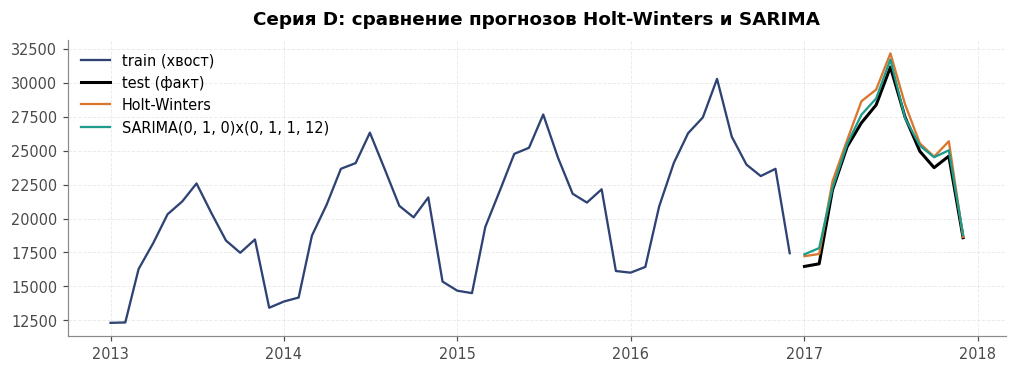

,Модель,rmse,mae,mape
0,Holt-Winters,896.692,819.440,3.403
1,"SARIMA(0, 1, 0)x(0, 1, 1, 12)",583.625,492.493,2.290


Ниже RMSE на тесте показала модель: SARIMA


In [54]:
fig, ax = plt.subplots()
ax.plot(train_D.index[-4*12:], train_D.values[-4*12:], label="train (хвост)")
ax.plot(test_D.index, test_D.values, label="test (факт)", color="black", lw=2)
ax.plot(test_D.index, hw_D["forecast"].values, label="Holt-Winters", color="#D9772E")
ax.plot(test_D.index, best_fc_D["forecast"].values, label=f"SARIMA{best_D['order']}x{best_D['seasonal_order']}", color="#1E9C8B")
ax.set_title(f"Серия D: сравнение прогнозов Holt-Winters и SARIMA")
ax.legend(); plt.show()

summary_D = pd.DataFrame([
    {"Модель": "Holt-Winters", **{k: round(v, 3) for k, v in hw_D["metrics"].items()}},
    {"Модель": f"SARIMA{best_D['order']}x{best_D['seasonal_order']}", **{k: round(v, 3) for k, v in best_fc_D["metrics"].items()}},
])
display(summary_D)
winner_D = "SARIMA" if best_fc_D["metrics"]["rmse"] < hw_D["metrics"]["rmse"] else "Holt-Winters"
print(f"Ниже RMSE на тесте показала модель: {winner_D}")

**Итоговое сравнение (серия D).**

| Модель | RMSE | MAE | MAPE |
|---|---|---|---|
| Holt-Winters | 896.66 | 819.41 | 3.40% |
| SARIMA(0, 1, 0)x(0, 1, 1, 12) | 583.63 | 492.49 | 2.29% |

На тестовой выборке ниже ошибку прогноза показала модель **SARIMA**.